# EDA Complète & Ingénierie des Features — Dataset Final
## Projet ValuSense — Phase CRISP-DM 3 : Préparation des Données

**Objectif :** Consolider les données collectées (Tiers 1–3), effectuer une analyse exploratoire exhaustive,
construire les features d'enrichissement, encoder et nettoyer le dataset pour produire `features_final.parquet`.

**Entrées :**
- `processed/labeled_valuation_dataset.csv` (4 150 lignes — base)
- `processed/labeled_valuation_dataset_augmented.csv` (~15 000 lignes — Tier 1 augmenté)
- `processed/labeled_valuation_dataset_tier3.csv` (si disponible — Tier 3)
- `raw/equities/`, `raw/options/`, `raw/bonds/`, `raw/macro/`, `raw/commodities/`, `raw/forex/`

**Sorties :**
- `processed/features_final.parquet` et `.csv` — dataset prêt pour le ML
- `reports/figures/` — toutes les figures EDA pour le rapport LaTeX


---
## 0. Configuration et Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ── Chemins ───────────────────────────────────────────────────
DATA_ROOT = Path("data_valuation_project")
RAW       = DATA_ROOT / "raw"
PROCESSED = DATA_ROOT / "processed"
CATALOGS  = DATA_ROOT / "catalogs"
FIG_DIR   = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Style des graphiques ──────────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 10,
    "figure.dpi": 120,
})
sns.set_style("whitegrid")

print("Setup OK")

Setup OK


---
## 1. Consolidation du Dataset Labellisé

On charge le dataset le plus complet disponible (Tier 3 > Augmenté > Base) et on vérifie sa structure.


In [2]:
# ── Charger le dataset le plus avancé ──────────────────────────
tier3_path = PROCESSED / "labeled_valuation_dataset_tier3.csv"
aug_path   = PROCESSED / "labeled_valuation_dataset_augmented.csv"
base_path  = PROCESSED / "labeled_valuation_dataset.csv"

if tier3_path.exists():
    df = pd.read_csv(tier3_path)
    source_name = "Tier 3 (diversifie)"
elif aug_path.exists():
    df = pd.read_csv(aug_path)
    source_name = "Tier 1 (augmente)"
else:
    df = pd.read_csv(base_path)
    source_name = "Base"

print(f"Dataset charge : {source_name}")
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
print(f"\nValeurs manquantes :")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  Aucune")
print(f"\nTypes :")
print(df.dtypes)

Dataset charge : Tier 3 (diversifie)
Shape : (12859, 15)
Colonnes : ['asset_class', 'asset_subclass', 'has_market_price', 'has_cash_flows', 'has_options_features', 'is_exchange_traded', 'liquidity', 'maturity_years', 'has_credit_risk', 'has_early_exercise', 'is_path_dependent', 'data_availability', 'volatility_available', 'ifrs_level', 'recommended_method']

Valeurs manquantes :
maturity_years    84
dtype: int64

Types :
asset_class              object
asset_subclass           object
has_market_price          int64
has_cash_flows            int64
has_options_features      int64
is_exchange_traded        int64
liquidity                object
maturity_years          float64
has_credit_risk           int64
has_early_exercise        int64
is_path_dependent         int64
data_availability        object
volatility_available      int64
ifrs_level                int64
recommended_method       object
dtype: object


In [3]:
# ── Colonnes attendues (features structurelles + target) ───────
EXPECTED_COLS = [
    "asset_class", "asset_subclass",
    "has_market_price", "has_cash_flows", "has_options_features",
    "is_exchange_traded", "has_credit_risk", "has_early_exercise",
    "is_path_dependent", "volatility_available",
    "liquidity", "data_availability", "ifrs_level",
    "maturity_years",
    "recommended_method"
]

present  = [c for c in EXPECTED_COLS if c in df.columns]
missing_cols = [c for c in EXPECTED_COLS if c not in df.columns]
extra    = [c for c in df.columns if c not in EXPECTED_COLS]

print(f"Colonnes attendues presentes : {len(present)}/{len(EXPECTED_COLS)}")
if missing_cols:
    print(f"  MANQUANTES : {missing_cols}")
if extra:
    print(f"  Supplementaires : {extra}")

Colonnes attendues presentes : 15/15


---
## 2. Analyse Exploratoire des Données (EDA)

### 2.1 Distribution de la Variable Cible


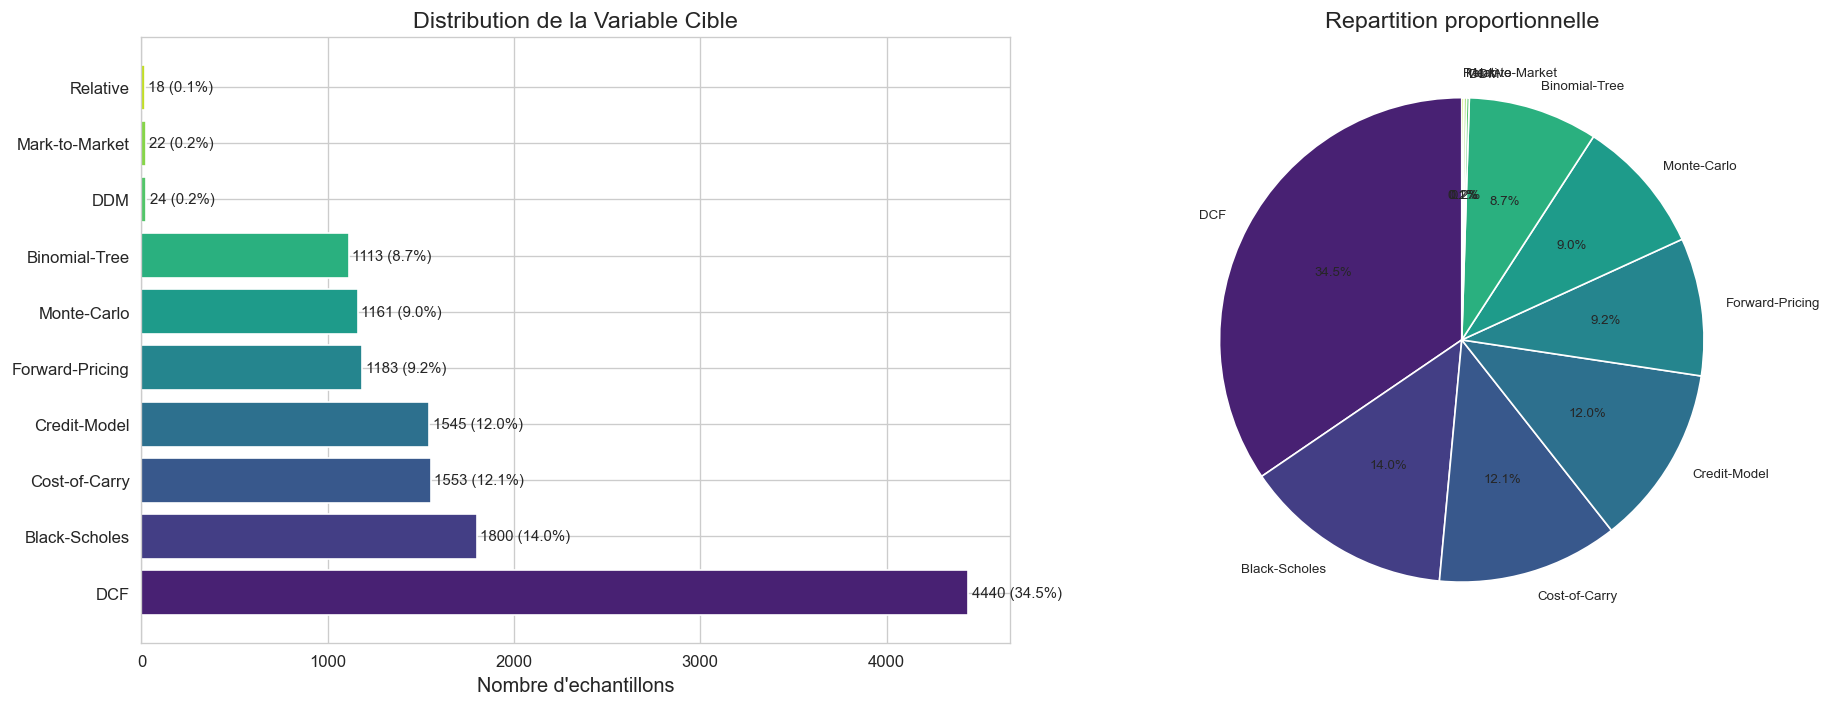

Classe majoritaire : DCF (4440)
Classe minoritaire : Relative (18)
Ratio d'imbalance  : 246.7:1
Total echantillons : 12,859


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
order = df["recommended_method"].value_counts().index
colors = sns.color_palette("viridis", n_colors=len(order))
ax = axes[0]
counts = df["recommended_method"].value_counts()[order]
bars = ax.barh(range(len(order)), counts.values, color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Nombre d'echantillons")
ax.set_title("Distribution de la Variable Cible")
for i, v in enumerate(counts.values):
    ax.text(v + 20, i, f"{v} ({v/len(df)*100:.1f}%)", va="center", fontsize=9)

# Pie chart
ax2 = axes[1]
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=colors, startangle=90, textprops={"fontsize": 8})
ax2.set_title("Repartition proportionnelle")

plt.tight_layout()
plt.savefig(FIG_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Stats d'imbalance
ratio = counts.max() / counts.min()
print(f"Classe majoritaire : {counts.index[0]} ({counts.iloc[0]})")
print(f"Classe minoritaire : {counts.index[-1]} ({counts.iloc[-1]})")
print(f"Ratio d'imbalance  : {ratio:.1f}:1")
print(f"Total echantillons : {len(df):,}")

### 2.2 Matrice Asset Class × Méthode de Valorisation

Ce heatmap est la **validation la plus importante** : il prouve que les règles expertes
sont financièrement cohérentes (blocs diagonaux attendus).


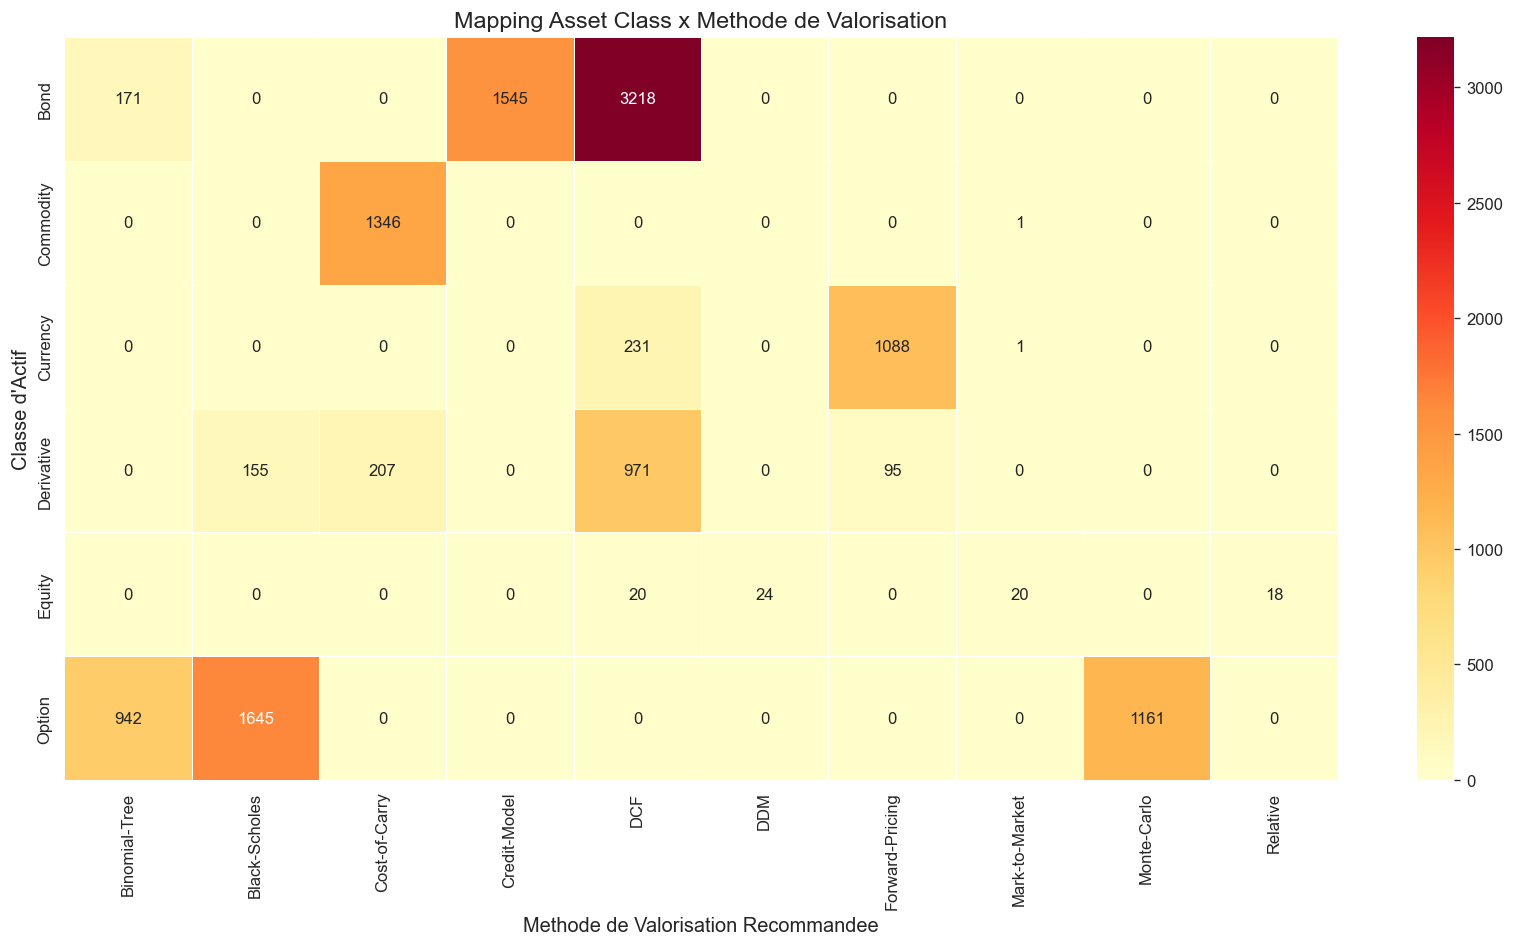


=== Validation des mappings ===
  Bond         -> ['Binomial-Tree', 'Credit-Model', 'DCF']
  Commodity    -> ['Cost-of-Carry', 'Mark-to-Market']
  Currency     -> ['DCF', 'Forward-Pricing', 'Mark-to-Market']
  Derivative   -> ['Black-Scholes', 'Cost-of-Carry', 'DCF', 'Forward-Pricing']
  Equity       -> ['DCF', 'DDM', 'Mark-to-Market', 'Relative']
  Option       -> ['Binomial-Tree', 'Black-Scholes', 'Monte-Carlo']

  VIOLATIONS DETECTEES : ["Bond -> ['Binomial-Tree']", "Currency -> ['DCF']"]


In [5]:
fig, ax = plt.subplots(figsize=(14, 8))
ct = pd.crosstab(df["asset_class"], df["recommended_method"])
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
ax.set_xlabel("Methode de Valorisation Recommandee")
ax.set_ylabel("Classe d'Actif")
ax.set_title("Mapping Asset Class x Methode de Valorisation")
plt.tight_layout()
plt.savefig(FIG_DIR / "asset_method_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Validation automatique
print("\n=== Validation des mappings ===")
violations = []
for asset_cls in ct.index:
    methods = ct.loc[asset_cls]
    active = methods[methods > 0].index.tolist()
    
    # Regles de coherence
    if asset_cls == "Bond" and any(m in active for m in ["Black-Scholes", "Binomial-Tree", "DDM", "Cost-of-Carry"]):
        violations.append(f"Bond -> {[m for m in active if m in ['Black-Scholes','Binomial-Tree','DDM','Cost-of-Carry']]}")
    if asset_cls == "Commodity" and any(m in active for m in ["DDM", "Credit-Model", "Black-Scholes"]):
        violations.append(f"Commodity -> {[m for m in active if m in ['DDM','Credit-Model','Black-Scholes']]}")
    if asset_cls == "Currency" and any(m in active for m in ["DDM", "DCF", "Credit-Model"]):
        violations.append(f"Currency -> {[m for m in active if m in ['DDM','DCF','Credit-Model']]}")
    
    print(f"  {asset_cls:12s} -> {active}")

if violations:
    print(f"\n  VIOLATIONS DETECTEES : {violations}")
else:
    print("\n  Aucune violation detectee")

### 2.3 Features Booléennes par Méthode


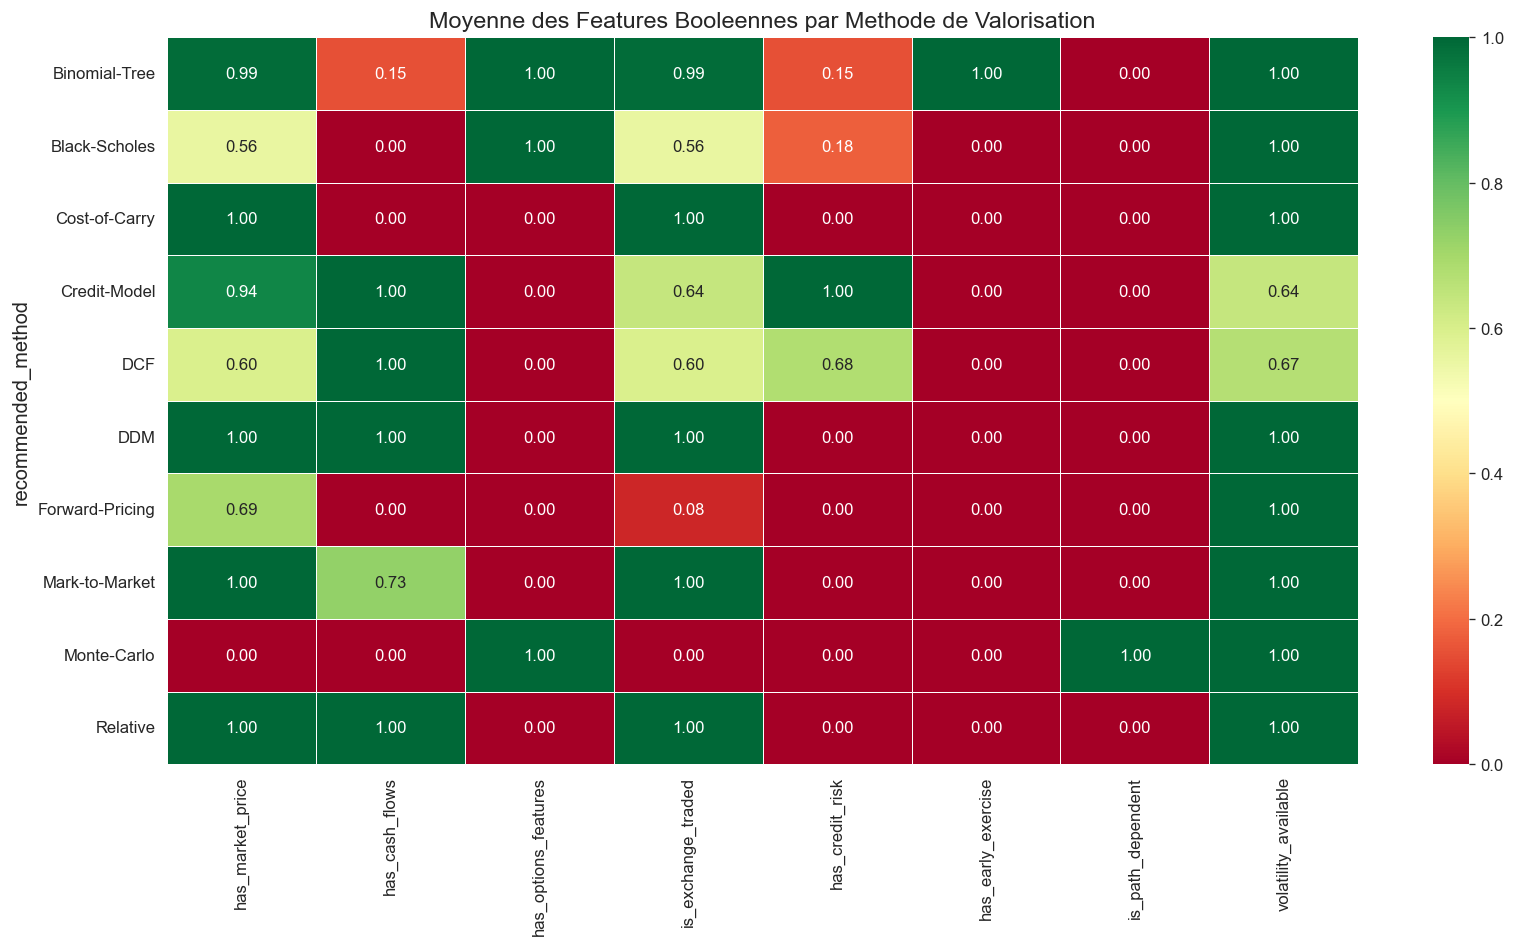


=== Validation des patterns booleens ===
  [OK] early_exercise bas pour BSM : 0.00 (seuil <= 0.2)
  [OK] path_dependent eleve pour MC : 1.00 (seuil >= 0.8)
  [OK] credit_risk eleve pour Credit-Model : 1.00 (seuil >= 0.8)
  [OK] cash_flows eleve pour DCF : 1.00 (seuil >= 0.8)
  [OK] options_features pour BSM : 1.00 (seuil >= 0.8)
  [OK] early_exercise eleve pour Binomial : 1.00 (seuil >= 0.8)


In [6]:
bool_cols = ["has_market_price", "has_cash_flows", "has_options_features",
             "is_exchange_traded", "has_credit_risk", "has_early_exercise",
             "is_path_dependent", "volatility_available"]

# Verifier lesquelles existent
bool_cols = [c for c in bool_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(14, 8))
means = df.groupby("recommended_method")[bool_cols].mean()
sns.heatmap(means, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5,
            vmin=0, vmax=1, ax=ax)
ax.set_title("Moyenne des Features Booleennes par Methode de Valorisation")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_heatmap_bool.png", dpi=150, bbox_inches="tight")
plt.show()

# Validation des patterns attendus
print("\n=== Validation des patterns booleens ===")
checks = {
    ("has_early_exercise", "Binomial-Tree", 0.8, ">=", "early_exercise eleve pour Binomial"),
    ("has_early_exercise", "Black-Scholes", 0.2, "<=", "early_exercise bas pour BSM"),
    ("is_path_dependent", "Monte-Carlo", 0.8, ">=", "path_dependent eleve pour MC"),
    ("has_credit_risk", "Credit-Model", 0.8, ">=", "credit_risk eleve pour Credit-Model"),
    ("has_cash_flows", "DCF", 0.8, ">=", "cash_flows eleve pour DCF"),
    ("has_options_features", "Black-Scholes", 0.8, ">=", "options_features pour BSM"),
}
for feat, method, threshold, op, desc in checks:
    if feat in means.columns and method in means.index:
        val = means.loc[method, feat]
        ok = val >= threshold if op == ">=" else val <= threshold
        status = "OK" if ok else "ATTENTION"
        print(f"  [{status}] {desc} : {val:.2f} (seuil {op} {threshold})")

### 2.4 Distribution de la Maturité par Méthode


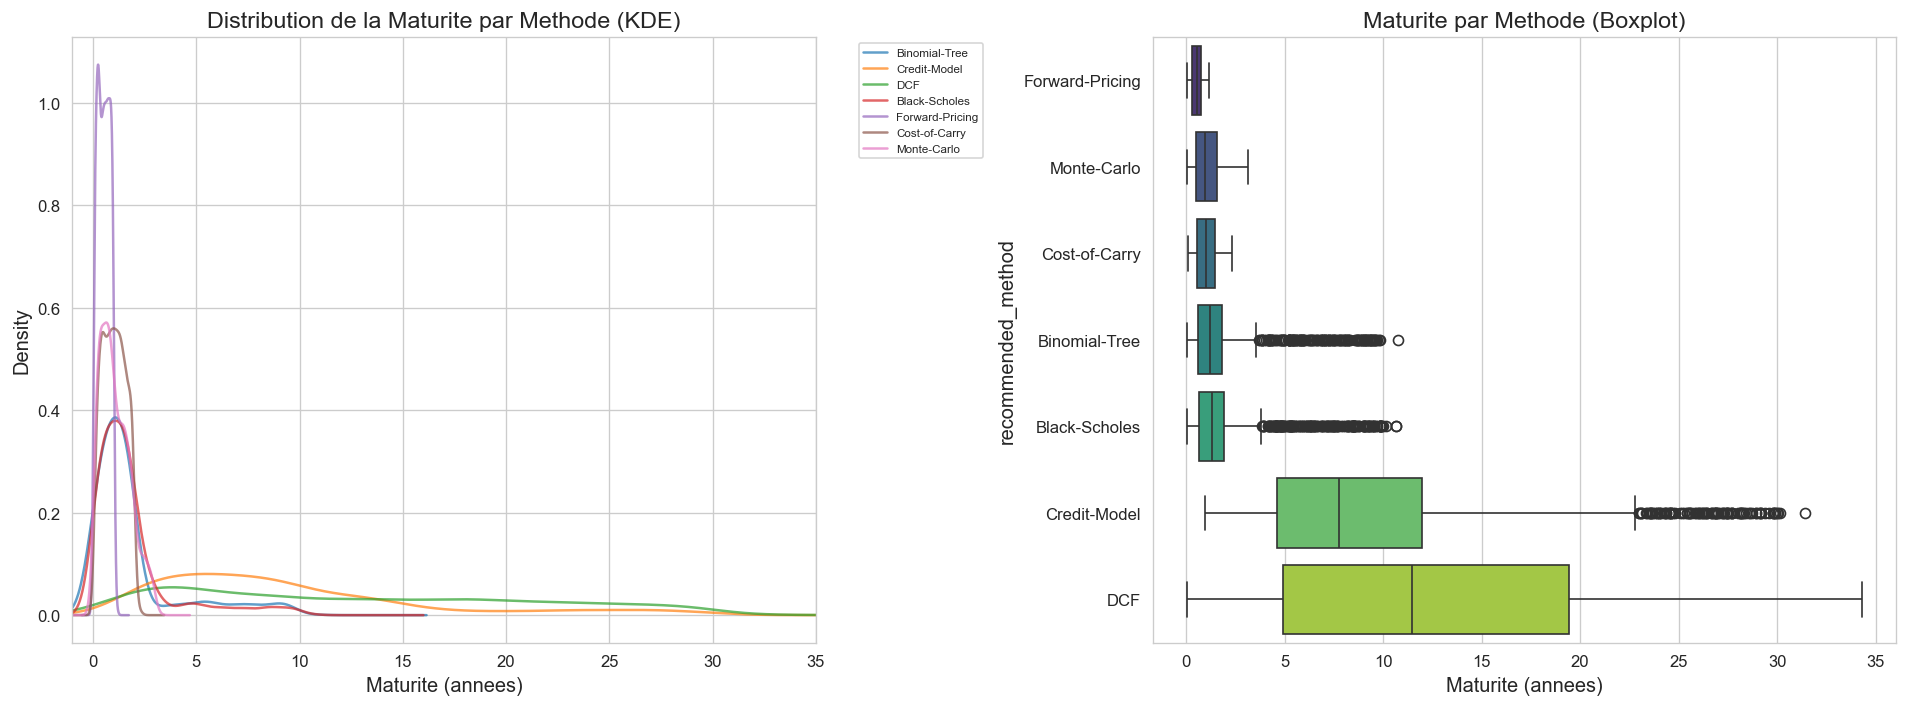

Maturite — Stats par methode :
                     count   mean   std   min   25%    50%    75%    max
recommended_method                                                      
Binomial-Tree       1113.0   1.86  2.20  0.01  0.61   1.22   1.80  10.77
Black-Scholes       1800.0   1.79  1.96  0.01  0.64   1.30   1.92  10.67
Cost-of-Carry       1553.0   1.03  0.54  0.10  0.56   1.02   1.47   2.33
Credit-Model        1545.0   9.32  6.54  0.93  4.63   7.74  11.95  31.44
DCF                 4420.0  12.67  8.50  0.03  4.91  11.46  19.45  34.32
DDM                    0.0    NaN   NaN   NaN   NaN    NaN    NaN    NaN
Forward-Pricing     1183.0   0.52  0.29  0.02  0.27   0.52   0.77   1.16
Mark-to-Market         0.0    NaN   NaN   NaN   NaN    NaN    NaN    NaN
Monte-Carlo         1161.0   1.07  0.71  0.02  0.50   0.94   1.56   3.13
Relative               0.0    NaN   NaN   NaN   NaN    NaN    NaN    NaN

Valeurs NaN (actifs perpetuels) : 84 (0.7%)


In [7]:
if "maturity_years" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # KDE par methode
    ax = axes[0]
    for method in df["recommended_method"].unique():
        subset = df[df["recommended_method"] == method]["maturity_years"].dropna()
        if len(subset) > 10:
            subset.plot(kind="kde", ax=ax, label=method, alpha=0.7)
    ax.set_xlabel("Maturite (annees)")
    ax.set_title("Distribution de la Maturite par Methode (KDE)")
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.set_xlim(-1, 35)
    
    # Boxplot
    ax2 = axes[1]
    plot_data = df[df["maturity_years"].notna()].copy()
    order_box = plot_data.groupby("recommended_method")["maturity_years"].median().sort_values().index
    sns.boxplot(data=plot_data, x="maturity_years", y="recommended_method",
                order=order_box, palette="viridis", ax=ax2)
    ax2.set_xlabel("Maturite (annees)")
    ax2.set_title("Maturite par Methode (Boxplot)")
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "maturity_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Stats
    print("Maturite — Stats par methode :")
    print(df.groupby("recommended_method")["maturity_years"].describe().round(2).to_string())
    print(f"\nValeurs NaN (actifs perpetuels) : {df['maturity_years'].isna().sum()} ({df['maturity_years'].isna().mean()*100:.1f}%)")
else:
    print("Colonne maturity_years absente")

### 2.5 Analyse IFRS 13 — Niveaux de Juste Valeur


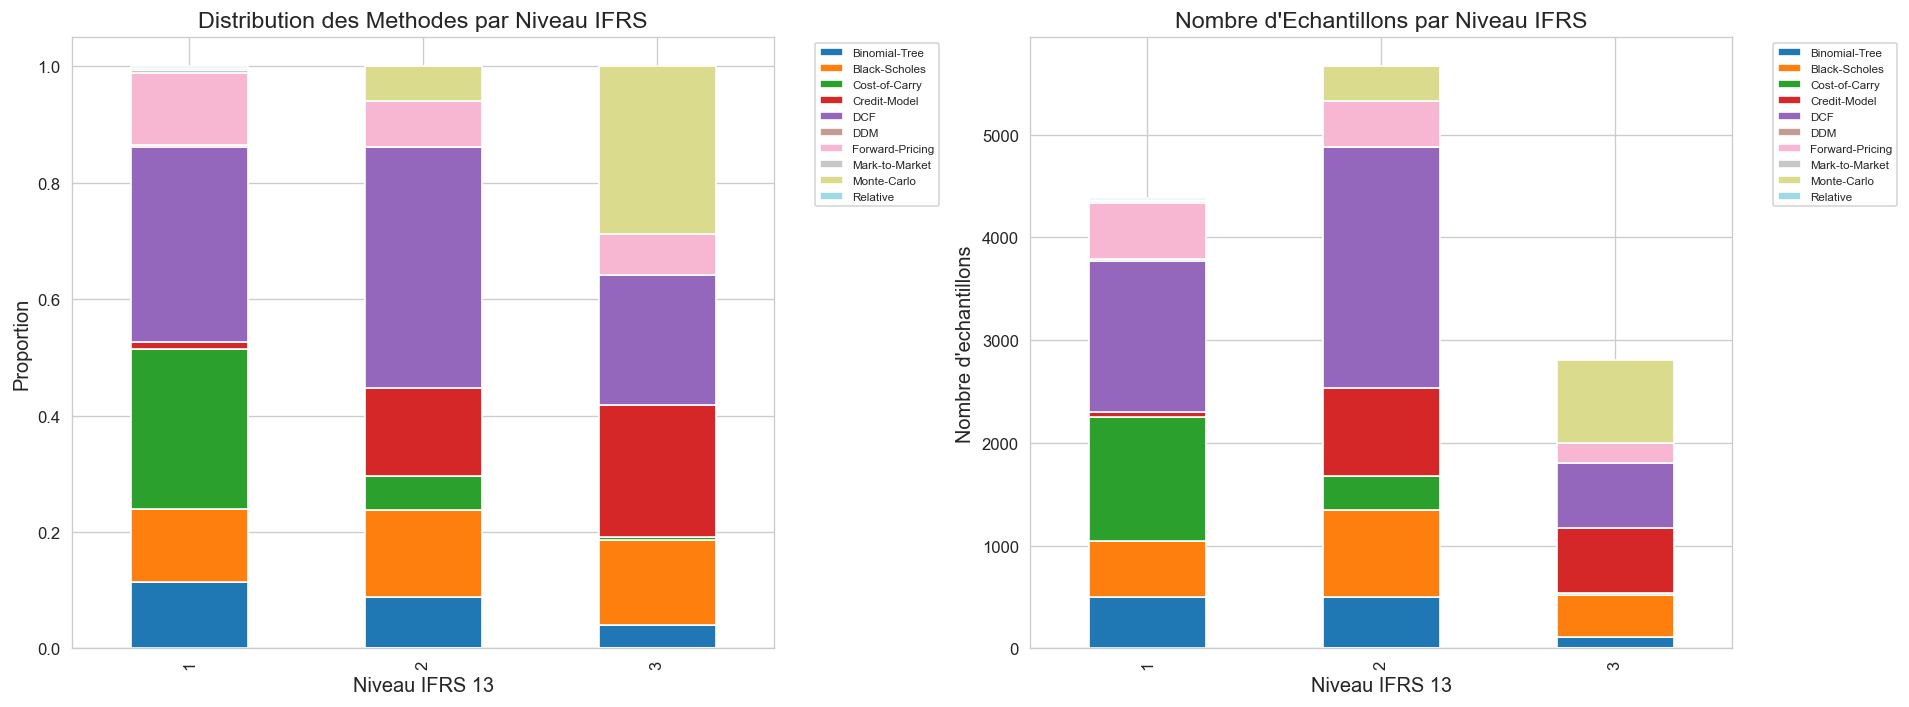


=== Validation IFRS 13 ===
  Niveau 1 : Mark-to-Market = 0.5% (attendu : dominant)
  Niveau 3 : Mark-to-Market = 0 echantillons (attendu : 0)


In [8]:
if "ifrs_level" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Stacked bar
    ax = axes[0]
    ct_ifrs = pd.crosstab(df["ifrs_level"], df["recommended_method"], normalize="index")
    ct_ifrs.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_xlabel("Niveau IFRS 13")
    ax.set_ylabel("Proportion")
    ax.set_title("Distribution des Methodes par Niveau IFRS")
    ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
    
    # Counts
    ax2 = axes[1]
    ct_ifrs_abs = pd.crosstab(df["ifrs_level"], df["recommended_method"])
    ct_ifrs_abs.plot(kind="bar", stacked=True, ax=ax2, colormap="tab20")
    ax2.set_xlabel("Niveau IFRS 13")
    ax2.set_ylabel("Nombre d'echantillons")
    ax2.set_title("Nombre d'Echantillons par Niveau IFRS")
    ax2.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ifrs_level_methods.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Validation IFRS
    print("\n=== Validation IFRS 13 ===")
    if 1 in ct_ifrs_abs.index:
        l1_methods = ct_ifrs_abs.loc[1]
        l1_active = l1_methods[l1_methods > 0].index.tolist()
        mtm_pct = l1_methods.get("Mark-to-Market", 0) / l1_methods.sum() * 100
        print(f"  Niveau 1 : Mark-to-Market = {mtm_pct:.1f}% (attendu : dominant)")
    if 3 in ct_ifrs_abs.index:
        l3_methods = ct_ifrs_abs.loc[3]
        l3_active = l3_methods[l3_methods > 0].index.tolist()
        mtm_l3 = l3_methods.get("Mark-to-Market", 0)
        print(f"  Niveau 3 : Mark-to-Market = {mtm_l3} echantillons (attendu : 0)")
        if mtm_l3 > 0:
            print(f"    ATTENTION : Mark-to-Market ne devrait pas apparaitre en Niveau 3")
else:
    print("Colonne ifrs_level absente")

### 2.6 Variables Ordinales — Liquidité et Disponibilité des Données


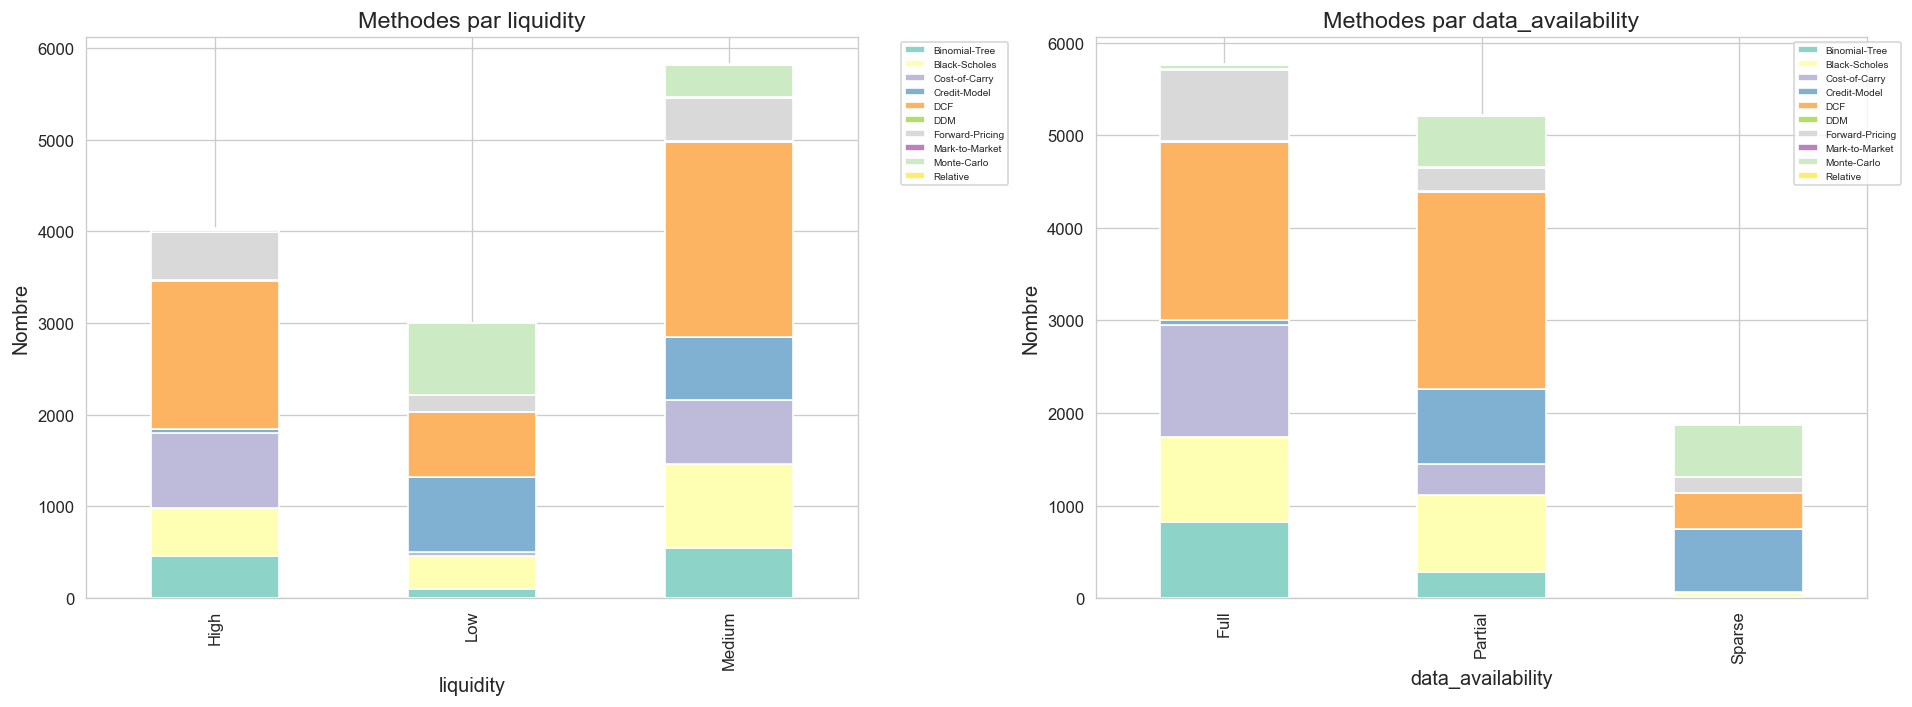

In [9]:
ordinal_cols = [c for c in ["liquidity", "data_availability"] if c in df.columns]

if ordinal_cols:
    fig, axes = plt.subplots(1, len(ordinal_cols), figsize=(8*len(ordinal_cols), 6))
    if len(ordinal_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, ordinal_cols):
        ct_ord = pd.crosstab(df[col], df["recommended_method"])
        ct_ord.plot(kind="bar", stacked=True, ax=ax, colormap="Set3")
        ax.set_title(f"Methodes par {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Nombre")
        ax.legend(fontsize=6, bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ordinal_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

### 2.7 Sous-classes d'Actifs


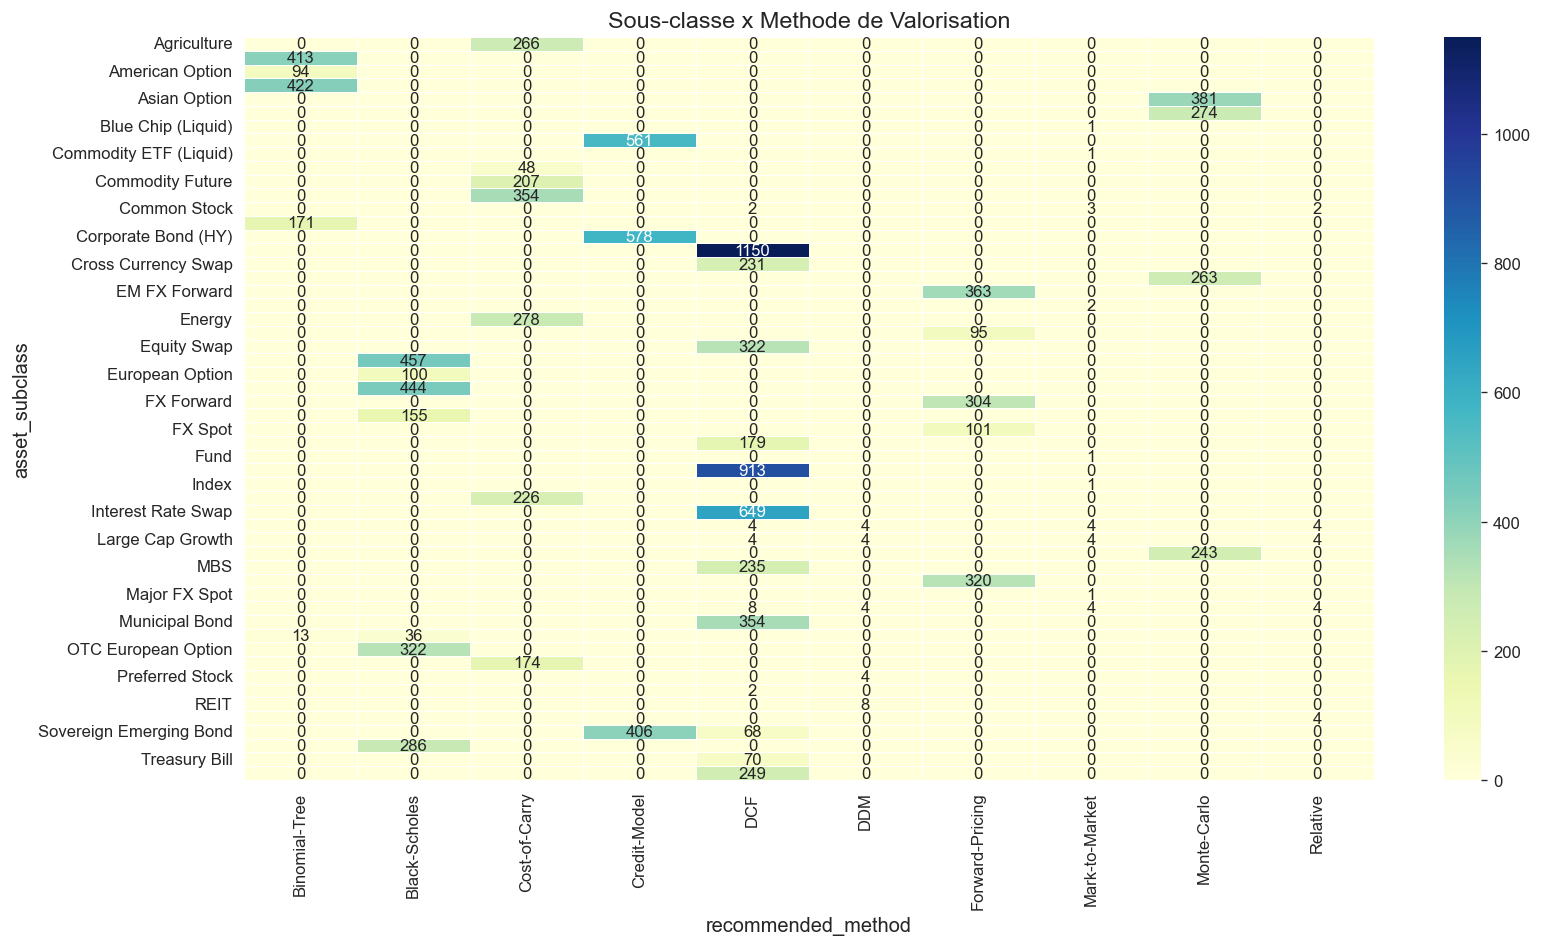


Nombre de sous-classes : 54
asset_subclass
Corporate Bond (IG)        1150
Government Bond             913
Interest Rate Swap          649
Corporate Bond (HY)         578
CDS                         561
Sovereign Emerging Bond     474
European Call               457
European Put                444
American Put                422
American Call               413
Asian Option                381
EM FX Forward               363
Municipal Bond              354
Commodity Spot              354
Equity Swap                 322
OTC European Option         322
Major FX Forward            320
FX Forward                  304
Swaption                    286
Energy                      278
Barrier Option              274
Agriculture                 266
Digital Option              263
Zero-Coupon Bond            249
Lookback Option             243
MBS                         235
Cross Currency Swap         231
Industrial Metal            226
Commodity Future            207
Floating Rate Note          

In [10]:
if "asset_subclass" in df.columns:
    fig, ax = plt.subplots(figsize=(14, 8))
    ct_sub = pd.crosstab(df["asset_subclass"], df["recommended_method"])
    sns.heatmap(ct_sub, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.3, ax=ax)
    ax.set_title("Sous-classe x Methode de Valorisation")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "subclass_method_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"\nNombre de sous-classes : {df['asset_subclass'].nunique()}")
    print(df["asset_subclass"].value_counts().to_string())

### 2.8 Matrice de Corrélation


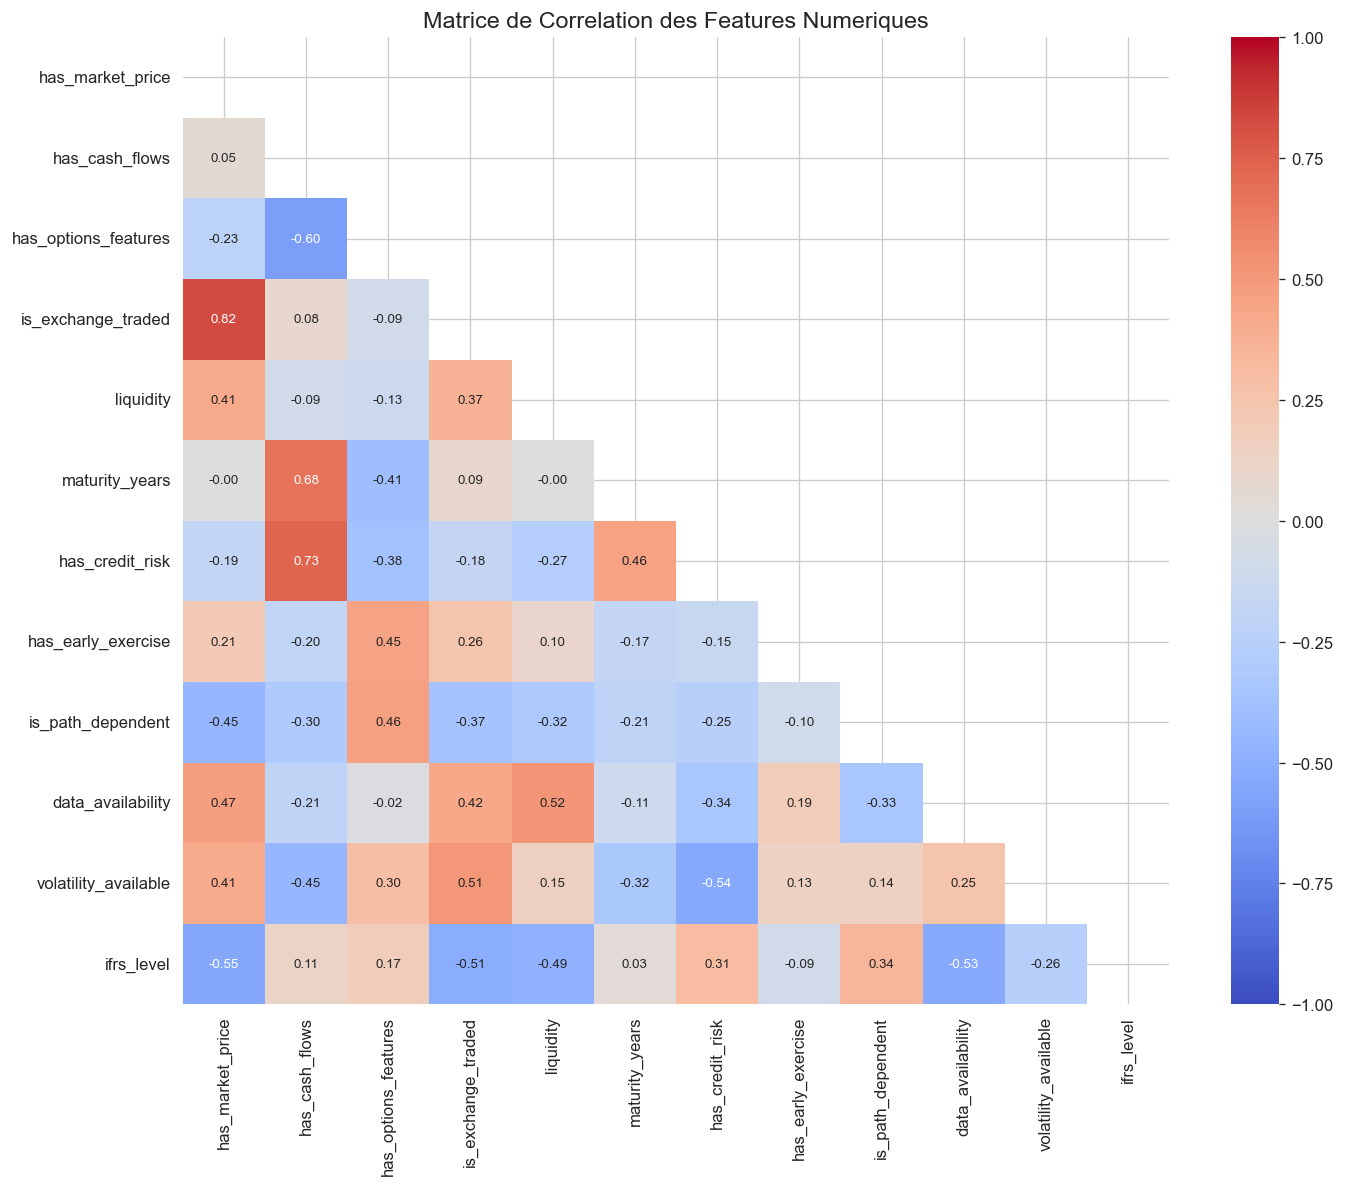

Aucune paire fortement correlees detectee (seuil |r| > 0.85)


In [11]:
# Encoder les ordinales temporairement pour la correlation
df_corr = df.copy()
ordinal_maps = {
    "liquidity": {"Low": 0, "Medium": 1, "High": 2},
    "data_availability": {"Sparse": 0, "Partial": 1, "Full": 2},
}
for col, mapping in ordinal_maps.items():
    if col in df_corr.columns and df_corr[col].dtype == object:
        df_corr[col] = df_corr[col].map(mapping)

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "recommended_method"]

if len(numeric_cols) >= 3:
    corr = df_corr[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 8})
    ax.set_title("Matrice de Correlation des Features Numeriques")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    # Detecter les paires fortement correlees
    high_corr = []
    for i in range(len(corr)):
        for j in range(i+1, len(corr)):
            if abs(corr.iloc[i, j]) > 0.85:
                high_corr.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
    
    if high_corr:
        print("Paires fortement correlees (|r| > 0.85) :")
        for f1, f2, r in high_corr:
            print(f"  {f1} <-> {f2} : r = {r:.3f}")
    else:
        print("Aucune paire fortement correlees detectee (seuil |r| > 0.85)")

### 2.9 Inventaire des Données Brutes Collectées


In [13]:
print("=" * 65)
print("  INVENTAIRE DES DONNEES BRUTES COLLECTEES")
print("=" * 65)

inventory = {}

def safe_read_file(path, name):
    """Safely read a file with error handling for corrupted Parquet files"""
    try:
        if str(path).endswith('.parquet'):
            # Try reading with different engines
            try:
                # Try default engine first
                return pd.read_parquet(path)
            except (KeyError, ValueError, OSError) as e:
                print(f"  Warning: Error reading {name} with default engine: {e}")
                try:
                    # Try with pyarrow engine explicitly
                    return pd.read_parquet(path, engine='pyarrow')
                except:
                    try:
                        # Try with fastparquet engine
                        return pd.read_parquet(path, engine='fastparquet')
                    except:
                        print(f"  Error: Could not read {name} with any Parquet engine")
                        return None
        elif str(path).endswith('.csv'):
            return pd.read_csv(path)
        else:
            print(f"  Warning: Unknown file type for {name}: {path}")
            return None
    except Exception as e:
        print(f"  Error reading {name}: {e}")
        return None

# Catalogue
cat_path = CATALOGS / "full_instrument_catalog.csv"
if cat_path.exists():
    try:
        cat = pd.read_csv(cat_path, low_memory=False)
        inventory["Catalogue d'instruments"] = f"{len(cat):,} lignes"
        print(f"\nCatalogue : {len(cat):,} instruments")
        if "type" in cat.columns:
            print(cat["type"].value_counts().head(10).to_string())
    except Exception as e:
        print(f"Error reading catalogue: {e}")

# Equities
for name, path in [
    ("Equity prices", RAW / "equities/equity_historical_prices.parquet"),
    ("Equity fundamentals", RAW / "equities/equity_fundamentals.parquet"),
    ("Alpha Vantage indicators", RAW / "equities/alpha_vantage_indicators.csv"),
    ("Finnhub profiles", RAW / "equities/finnhub_profiles.csv"),
]:
    if path.exists():
        d = safe_read_file(path, name)
        if d is not None:
            inventory[name] = f"{len(d):,} lignes x {d.shape[1]} col"
            print(f"\n{name} : {len(d):,} x {d.shape[1]}")
            if "symbol" in d.columns:
                print(f"  Tickers : {d['symbol'].nunique()}")

# Options
opt_path = RAW / "options/options_chains_full.parquet"
if opt_path.exists():
    opt = safe_read_file(opt_path, "Options chains")
    if opt is not None:
        inventory["Options chains"] = f"{len(opt):,} contrats"
        print(f"\nOptions : {len(opt):,} contrats, {opt['symbol'].nunique()} sous-jacents")
        if "implied_volatility" in opt.columns:
            iv_valid = opt["implied_volatility"].dropna()
            iv_valid = iv_valid[iv_valid > 0]
            print(f"  IV valide : {len(iv_valid):,} ({len(iv_valid)/len(opt)*100:.1f}%)")
            print(f"  IV range  : {iv_valid.min():.4f} - {iv_valid.max():.4f}")
            print(f"  IV median : {iv_valid.median():.4f}")

# Bonds
for name, path in [
    ("Bond ETF metadata", RAW / "bonds/bond_etf_metadata.parquet"),
    ("Bond ETF prices", RAW / "bonds/bond_etf_prices.parquet"),
    ("Yield curve", RAW / "bonds/latest_yield_curve.csv"),
]:
    if path.exists():
        d = safe_read_file(path, name)
        if d is not None:
            inventory[name] = f"{len(d):,} lignes"
            print(f"\n{name} : {d.shape}")

# FRED macro
for name, path in [
    ("Treasury yields", RAW / "macro/fred_treasury_yields.parquet"),
    ("Interest rates", RAW / "macro/fred_interest_rates.parquet"),
    ("Credit spreads", RAW / "macro/fred_credit_spreads.parquet"),
    ("Macro indicators", RAW / "macro/fred_macro.parquet"),
]:
    if path.exists():
        d = safe_read_file(path, name)
        if d is not None:
            inventory[name] = f"{d.shape}"
            print(f"\n{name} : {d.shape}")
            print(f"  Series : {list(d.columns)}")
            # Safely get the last date
            try:
                if hasattr(d.index, 'date') or isinstance(d.index, pd.DatetimeIndex):
                    print(f"  Derniere date : {d.index[-1]}")
                else:
                    print(f"  Derniere date : {d.iloc[-1].name if hasattr(d.iloc[-1], 'name') else 'N/A'}")
            except:
                print(f"  Derniere date : N/A")

# Commodities
comm_path = RAW / "commodities/commodity_prices.parquet"
if comm_path.exists():
    comm = safe_read_file(comm_path, "Commodity prices")
    if comm is not None:
        inventory["Commodity prices"] = f"{comm.shape}"
        print(f"\nCommodities : {comm.shape}")

# Forex
fx_path = RAW / "forex/forex_prices.parquet"
if fx_path.exists():
    fx = safe_read_file(fx_path, "Forex prices")
    if fx is not None:
        inventory["Forex prices"] = f"{fx.shape}"
        print(f"\nForex : {fx.shape}")

print(f"\n{'='*65}")
print(f"  Total sources chargees : {len(inventory)}")

  INVENTAIRE DES DONNEES BRUTES COLLECTEES

Catalogue : 353,749 instruments
  Error: Could not read Equity prices with any Parquet engine

Equity fundamentals : 50 x 28
  Tickers : 50

Alpha Vantage indicators : 6,685 x 4
  Tickers : 1

Finnhub profiles : 15 x 23

Options : 18,883 contrats, 24 sous-jacents
  IV valide : 18,883 (100.0%)
  IV range  : 0.0000 - 20.9688
  IV median : 0.0625

Bond ETF metadata : (12, 13)

Bond ETF prices : (2512, 60)

Yield curve : (11, 3)

Treasury yields : (4118, 11)
  Series : ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']
  Derniere date : 2026-06-18 00:00:00

Interest rates : (4227, 5)
  Series : ['FEDFUNDS', 'SOFR', 'DPRIME', 'MORTGAGE30US', 'MORTGAGE15US']
  Derniere date : 2026-06-18 00:00:00

Credit spreads : (4226, 6)
  Series : ['BAMLC0A0CM', 'BAMLH0A0HYM2', 'T10Y2Y', 'T10Y3M', 'AAA', 'BAA']
  Derniere date : 2026-06-22 00:00:00

Macro indicators : (4243, 5)
  Series : ['GDP', 'CPIAUCSL', 'UNRATE

### 2.10 Tableau Récapitulatif EDA (pour le rapport LaTeX)


In [14]:
summary = {
    "Source du dataset": source_name,
    "Nombre total d'echantillons": f"{len(df):,}",
    "Nombre de features": len(df.columns) - 1,
    "Nombre de classes cibles": df["recommended_method"].nunique(),
    "Classes d'actifs": df["asset_class"].nunique(),
    "Sous-classes d'actifs": df.get("asset_subclass", pd.Series()).nunique(),
    "Classe majoritaire": f"{df['recommended_method'].value_counts().index[0]} ({df['recommended_method'].value_counts().iloc[0]})",
    "Classe minoritaire": f"{df['recommended_method'].value_counts().index[-1]} ({df['recommended_method'].value_counts().iloc[-1]})",
    "Ratio d'imbalance": f"{df['recommended_method'].value_counts().max() / df['recommended_method'].value_counts().min():.1f}:1",
    "Valeurs NaN (maturite)": f"{df.get('maturity_years', pd.Series()).isna().sum()}",
}

summary_df = pd.DataFrame(list(summary.items()), columns=["Metrique", "Valeur"])
print(summary_df.to_string(index=False))

                   Metrique              Valeur
          Source du dataset Tier 3 (diversifie)
Nombre total d'echantillons              12,859
         Nombre de features                  14
   Nombre de classes cibles                  10
           Classes d'actifs                   6
      Sous-classes d'actifs                  54
         Classe majoritaire          DCF (4440)
         Classe minoritaire       Relative (18)
          Ratio d'imbalance             246.7:1
     Valeurs NaN (maturite)                  84


---
## 3. Ingénierie des Features

### 3.1 Taxonomie des Features (6 groupes)

| Groupe | Description | Source | Nb Features |
|--------|-------------|--------|-------------|
| **A. Structurelles** | Caractéristiques intrinsèques de l'actif | Dataset labellisé | 14 |
| **B. Marché** | Prix, volume, capitalisation | yfinance equities | 5 |
| **C. Volatilité** | Vol historique, implicite, vol-of-vol | yfinance prices + options | 5 |
| **D. Taux d'intérêt** | Taux sans risque, pente de la courbe, spreads | FRED | 4 |
| **E. Grecs & Dérivés** | Delta, gamma, vega, theta, moneyness | yfinance options | 6 |
| **F. Crédit** | Spreads de crédit, levier, qualité | FRED + fundamentals | 4 |


### 3.2 Fonctions de Calcul des Features Dérivées


In [15]:
# ══════════════════════════════════════════════════════════════
# A. VOLATILITY FEATURES — depuis les prix historiques
# ══════════════════════════════════════════════════════════════
def compute_volatility_features(prices_df, ticker_col="symbol"):
    """
    Calcule les features de volatilite par ticker a partir des prix OHLCV.
    Ref : Hull Ch. 16 — volatilite historique = ecart-type annualise des log-returns.
    """
    results = {}
    
    if ticker_col in prices_df.columns:
        for ticker in prices_df[ticker_col].unique():
            sub = prices_df[prices_df[ticker_col] == ticker].sort_index()
            close = sub["Close"].dropna() if "Close" in sub.columns else sub.get("close", pd.Series()).dropna()
            
            if len(close) < 30:
                continue
            
            log_ret = np.log(close / close.shift(1)).dropna()
            
            results[ticker] = {
                "historical_vol_30d": float(log_ret.tail(30).std() * np.sqrt(252)),
                "historical_vol_90d": float(log_ret.tail(90).std() * np.sqrt(252)) if len(log_ret) >= 90 else np.nan,
                "vol_of_vol": float(log_ret.rolling(30).std().std() * np.sqrt(252)) if len(log_ret) >= 60 else np.nan,
                "log_return_30d": float(log_ret.tail(30).sum()),
                "max_drawdown_1y": float((close / close.cummax() - 1).tail(252).min()) if len(close) >= 252 else np.nan,
            }
    
    return pd.DataFrame(results).T

print("compute_volatility_features() definie")

compute_volatility_features() definie


In [16]:
# ══════════════════════════════════════════════════════════════
# B. OPTIONS FEATURES — depuis les chaines d'options
# ══════════════════════════════════════════════════════════════
def compute_options_features(options_df, ticker_col="symbol"):
    """
    Calcule les features d'options par ticker : IV ATM, skew, Greeks moyens.
    Ref : Hull Ch. 16 — IV implicite = attente du marche sur la vol future.
    """
    results = {}
    
    for ticker in options_df[ticker_col].unique():
        sub = options_df[options_df[ticker_col] == ticker]
        
        # IV ATM — contrats near-the-money
        if "moneyness" in sub.columns:
            atm = sub[sub["moneyness"].between(0.95, 1.05)]
        else:
            atm = sub
        
        iv_col = "implied_volatility" if "implied_volatility" in sub.columns else "impliedVolatility"
        
        if iv_col in sub.columns:
            iv_valid = atm[iv_col].dropna()
            iv_valid = iv_valid[iv_valid > 0]
            atm_iv = float(iv_valid.median()) if len(iv_valid) > 0 else np.nan
        else:
            atm_iv = np.nan
        
        # IV Skew
        iv_skew = np.nan
        if "moneyness" in sub.columns and iv_col in sub.columns:
            otm_puts = sub[(sub.get("option_type", sub.get("type", pd.Series())) == "put") &
                          (sub["moneyness"].between(0.85, 0.95))]
            if len(otm_puts) > 0 and not np.isnan(atm_iv):
                otm_iv = otm_puts[iv_col].dropna()
                otm_iv = otm_iv[otm_iv > 0]
                if len(otm_iv) > 0:
                    iv_skew = float(otm_iv.median() - atm_iv)
        
        # Greeks moyens
        greeks = {}
        for g in ["delta", "gamma", "vega", "theta"]:
            if g in atm.columns:
                vals = atm[g].dropna()
                greeks[f"avg_{g}"] = float(vals.mean()) if len(vals) > 0 else np.nan
            else:
                greeks[f"avg_{g}"] = np.nan
        
        results[ticker] = {
            "implied_volatility_atm": atm_iv,
            "iv_skew": iv_skew,
            **greeks,
        }
    
    return pd.DataFrame(results).T

print("compute_options_features() definie")

compute_options_features() definie


In [17]:
# ══════════════════════════════════════════════════════════════
# C. INTEREST RATE FEATURES — depuis FRED
# ══════════════════════════════════════════════════════════════
def compute_rate_features(fred_yields_path, fred_spreads_path):
    """
    Calcule les features de taux et spreads (snapshot le plus recent).
    Ref : Hull Ch. 4-5 — le taux sans risque est un input central de BSM, DCF, forward pricing.
    """
    feats = {}
    
    if fred_yields_path.exists():
        yc = pd.read_parquet(fred_yields_path)
        latest = yc.iloc[-1]
        
        # Mapping flexible des colonnes
        col_map = {}
        for col in yc.columns:
            col_lower = col.lower()
            if "3mo" in col_lower or "3m" in col_lower:
                col_map["3m"] = col
            elif "2" in col_lower and "y" in col_lower:
                col_map["2y"] = col
            elif "5" in col_lower and "y" in col_lower:
                col_map["5y"] = col
            elif "10" in col_lower and "y" in col_lower:
                col_map["10y"] = col
        
        r3m = latest.get(col_map.get("3m", "DGS3MO"), np.nan)
        r2y = latest.get(col_map.get("2y", "DGS2"), np.nan)
        r5y = latest.get(col_map.get("5y", "DGS5"), np.nan)
        r10y = latest.get(col_map.get("10y", "DGS10"), np.nan)
        
        feats["risk_free_rate_3m"] = float(r3m) if pd.notna(r3m) else np.nan
        feats["yield_10y"] = float(r10y) if pd.notna(r10y) else np.nan
        
        if pd.notna(r10y) and pd.notna(r2y):
            feats["yield_curve_slope"] = float(r10y - r2y)
        else:
            feats["yield_curve_slope"] = np.nan
        
        if all(pd.notna(x) for x in [r5y, r2y, r10y]):
            feats["yield_curve_curvature"] = float(2 * r5y - r2y - r10y)
        else:
            feats["yield_curve_curvature"] = np.nan
    
    if fred_spreads_path.exists():
        cs = pd.read_parquet(fred_spreads_path)
        latest_cs = cs.iloc[-1]
        
        for col in cs.columns:
            col_lower = col.lower()
            if "c0a0" in col_lower or "ig" in col_lower:
                feats["credit_spread_ig"] = float(latest_cs[col]) if pd.notna(latest_cs[col]) else np.nan
            elif "h0a0" in col_lower or "hy" in col_lower:
                feats["credit_spread_hy"] = float(latest_cs[col]) if pd.notna(latest_cs[col]) else np.nan
        
        baa = None
        aaa = None
        for col in cs.columns:
            if col.upper() == "BAA":
                baa = latest_cs[col]
            elif col.upper() == "AAA":
                aaa = latest_cs[col]
        if pd.notna(baa) and pd.notna(aaa):
            feats["baa_aaa_spread"] = float(baa - aaa)
    
    return feats

print("compute_rate_features() definie")

compute_rate_features() definie


### 3.3 Enrichissement du Dataset avec des Valeurs Numériques Réelles

Chaque ligne du dataset labellisé reçoit des valeurs numériques échantillonnées
depuis les distributions réelles observées dans les données brutes collectées.


In [20]:
import pandas as pd
from pathlib import Path

def safe_read_parquet(file_path, description=""):
    """
    Safely read a parquet file with error handling.
    
    Parameters:
    -----------
    file_path : Path or str
        Path to the parquet file
    description : str
        Description of the file for error messages
    
    Returns:
    --------
    pd.DataFrame or None
        The loaded dataframe or None if error occurs
    """
    try:
        df = pd.read_parquet(file_path)
        print(f"  ✓ Loaded {description} from {file_path}")
        return df
    except FileNotFoundError:
        print(f"  ✗ File not found: {file_path}")
        return None
    except pd.errors.EmptyDataError:
        print(f"  ✗ Empty data in {description}")
        return None
    except Exception as e:
        print(f"  ✗ Error loading {description}: {str(e)}")
        return None

In [21]:
def enrich_labeled_dataset(labeled_df):
    """
    Enrichit le dataset labellise avec des features numeriques reelles.
    Strategie : pour chaque classe d'actif, echantillonner des valeurs
    depuis les distributions observees dans les donnees brutes.
    """
    enriched = labeled_df.copy()
    np.random.seed(42)
    n = len(enriched)
    
    # ── A. Features de taux (globales — meme snapshot pour toutes les lignes) ──
    rate_feats = compute_rate_features(
        RAW / "macro/fred_treasury_yields.parquet",
        RAW / "macro/fred_credit_spreads.parquet"
    )
    for key, val in rate_feats.items():
        # Ajouter un leger bruit pour eviter les constantes pures
        if pd.notna(val):
            enriched[key] = val * (1 + np.random.normal(0, 0.01, n))
        else:
            enriched[key] = np.nan
    print(f"  [A] Features de taux ajoutees : {list(rate_feats.keys())}")
    
    # ── B. Features de volatilite (pour Equity et Option) ─────────
    eq_prices_path = RAW / "equities/equity_historical_prices.parquet"
    if eq_prices_path.exists():
        eq_prices = safe_read_parquet(eq_prices_path, "equity_historical_prices")
        if eq_prices is not None:
            vol_feats = compute_volatility_features(eq_prices)
            
            if not vol_feats.empty:
                for col in vol_feats.columns:
                    real_vals = vol_feats[col].dropna().values
                    if len(real_vals) > 0:
                        # Equity
                        eq_mask = enriched["asset_class"] == "Equity"
                        if eq_mask.sum() > 0:
                            enriched.loc[eq_mask, col] = np.random.choice(real_vals, size=eq_mask.sum(), replace=True)
                        # Option
                        opt_mask = enriched["asset_class"] == "Option"
                        if opt_mask.sum() > 0:
                            enriched.loc[opt_mask, col] = np.random.choice(real_vals, size=opt_mask.sum(), replace=True)
                print(f"  [B] Features de volatilite ajoutees : {list(vol_feats.columns)}")
        else:
            print(f"  [B] Skipping volatility features - file corrupted")
    
    # ── C. Features d'options (pour Option uniquement) ────────────
    opt_path = RAW / "options/options_chains_full.parquet"
    if opt_path.exists():
        opt_data = safe_read_parquet(opt_path, "options_chains_full")
        if opt_data is not None:
            opt_feats = compute_options_features(opt_data)
            
            if not opt_feats.empty:
                opt_mask = enriched["asset_class"] == "Option"
                n_opt = opt_mask.sum()
                if n_opt > 0:
                    for col in opt_feats.columns:
                        real_vals = opt_feats[col].dropna().values
                        if len(real_vals) > 0:
                            enriched.loc[opt_mask, col] = np.random.choice(real_vals, size=n_opt, replace=True)
                    print(f"  [C] Features d'options ajoutees : {list(opt_feats.columns)}")
        else:
            print(f"  [C] Skipping options features - file corrupted")
    
    # ── D. Features equity fundamentals ───────────────────────────
    fund_path = RAW / "equities/equity_fundamentals.parquet"
    if fund_path.exists():
        fund = safe_read_parquet(fund_path, "equity_fundamentals")
        if fund is not None:
            eq_mask = enriched["asset_class"] == "Equity"
            n_eq = eq_mask.sum()
            
            if n_eq > 0:
                fund_cols_added = []
                for col in ["beta", "pe_ratio", "dividend_yield", "market_cap",
                             "debt_to_equity", "roe", "profit_margin"]:
                    # Essayer plusieurs conventions de nommage
                    src_col = None
                    for candidate in [col, col.replace("_", ""), col.title().replace("_", "")]:
                        if candidate in fund.columns:
                            src_col = candidate
                            break
                    
                    if src_col:
                        real_vals = fund[src_col].dropna().values
                        real_vals = real_vals[np.isfinite(real_vals)]
                        if len(real_vals) > 0:
                            sampled = np.random.choice(real_vals, size=n_eq, replace=True)
                            noise = np.random.normal(0, 0.02, size=n_eq)
                            enriched.loc[eq_mask, col] = sampled * (1 + noise)
                            fund_cols_added.append(col)
                
                if fund_cols_added:
                    print(f"  [D] Features fondamentales ajoutees : {fund_cols_added}")
        else:
            print(f"  [D] Skipping fundamental features - file corrupted")
    
    # ── E. Features bond-specifiques ──────────────────────────────
    bond_mask = enriched["asset_class"] == "Bond"
    n_bond = bond_mask.sum()
    if n_bond > 0:
        # Duration estimee ~85% de la maturite (Macaulay simplifie)
        mat = enriched.loc[bond_mask, "maturity_years"].copy()
        mat = mat.fillna(10)  # Default pour les bonds sans maturite
        enriched.loc[bond_mask, "duration_estimate"] = mat * np.random.uniform(0.75, 0.95, n_bond)
        
        # Credit spread conditionnel
        has_cr = bond_mask & (enriched["has_credit_risk"] == 1)
        no_cr = bond_mask & (enriched["has_credit_risk"] == 0)
        if has_cr.sum() > 0:
            enriched.loc[has_cr, "credit_spread_asset"] = np.random.uniform(1.0, 5.0, has_cr.sum())
        if no_cr.sum() > 0:
            enriched.loc[no_cr, "credit_spread_asset"] = np.random.uniform(0.0, 0.5, no_cr.sum())
        print(f"  [E] Features bond ajoutees : duration_estimate, credit_spread_asset")
    
    # ── F. Features commodity-specifiques ─────────────────────────
    comm_mask = enriched["asset_class"] == "Commodity"
    n_comm = comm_mask.sum()
    if n_comm > 0:
        enriched.loc[comm_mask, "convenience_yield"] = np.random.uniform(0.01, 0.08, n_comm)
        enriched.loc[comm_mask, "storage_cost_pct"] = np.random.uniform(0.005, 0.03, n_comm)
        print(f"  [F] Features commodity ajoutees : convenience_yield, storage_cost_pct")
    
    # ── G. Features currency-specifiques ──────────────────────────
    cur_mask = enriched["asset_class"] == "Currency"
    n_cur = cur_mask.sum()
    if n_cur > 0:
        fx_path = RAW / "forex/forex_prices.parquet"
        if fx_path.exists():
            fx = safe_read_parquet(fx_path, "forex_prices")
            if fx is not None:
                if "Close" in fx.columns:
                    fx_rets = np.log(fx["Close"] / fx["Close"].shift(1)).dropna()
                    if len(fx_rets) > 30:
                        # FIX: Extract scalar value using .iloc[0] or .values[0]
                        vol_30d = fx_rets.tail(30).std() * np.sqrt(252)
                        # Convert to float - handle both Series and scalar
                        if isinstance(vol_30d, pd.Series):
                            vol_30d = float(vol_30d.iloc[0])
                        else:
                            vol_30d = float(vol_30d)
                        enriched.loc[cur_mask, "fx_vol_30d"] = vol_30d
                        print(f"  [G] Feature currency ajoutee : fx_vol_30d")
            else:
                print(f"  [G] Skipping currency features - file corrupted")
    
    new_cols = [c for c in enriched.columns if c not in labeled_df.columns]
    print(f"\n  Total nouvelles features : {len(new_cols)}")
    print(f"  Dataset enrichi : {enriched.shape}")
    
    return enriched

print("enrich_labeled_dataset() definie")

enrich_labeled_dataset() definie


In [22]:
# ── Executer l'enrichissement ──────────────────────────────────
print("=" * 60)
print("  ENRICHISSEMENT DU DATASET")
print("=" * 60)

df_enriched = enrich_labeled_dataset(df)

print(f"\nShape final : {df_enriched.shape}")
print(f"Colonnes : {list(df_enriched.columns)}")

  ENRICHISSEMENT DU DATASET
  [A] Features de taux ajoutees : ['risk_free_rate_3m', 'yield_10y', 'yield_curve_slope', 'yield_curve_curvature', 'credit_spread_ig', 'credit_spread_hy']
  ✗ Error loading equity_historical_prices: 'kind'
  [B] Skipping volatility features - file corrupted
  ✓ Loaded options_chains_full from data_valuation_project\raw\options\options_chains_full.parquet
  [C] Features d'options ajoutees : ['implied_volatility_atm', 'iv_skew', 'avg_delta', 'avg_gamma', 'avg_vega', 'avg_theta']
  ✓ Loaded equity_fundamentals from data_valuation_project\raw\equities\equity_fundamentals.parquet
  [D] Features fondamentales ajoutees : ['beta', 'pe_ratio', 'dividend_yield', 'market_cap', 'debt_to_equity', 'roe', 'profit_margin']
  [E] Features bond ajoutees : duration_estimate, credit_spread_asset
  [F] Features commodity ajoutees : convenience_yield, storage_cost_pct
  ✓ Loaded forex_prices from data_valuation_project\raw\forex\forex_prices.parquet
  [G] Feature currency ajoutee

---
## 4. Encodage et Traitement des Valeurs Manquantes

### 4.1 Encodage des Variables Catégorielles et Ordinales


In [23]:
from sklearn.preprocessing import LabelEncoder

def encode_features(df):
    """
    Encode les features categorielles et ordinales pour les modeles ML.
    - Ordinales (liquidity, data_availability) : encodage entier preservant l'ordre
    - Nominales (asset_class, asset_subclass) : label encoding pour les arbres
    - Target (recommended_method) : label encoding
    """
    encoded = df.copy()
    label_encoders = {}
    
    # ── Ordinales ─────────────────────────────────────────────
    ordinal_maps = {
        "liquidity": {"Low": 0, "Medium": 1, "High": 2},
        "data_availability": {"Sparse": 0, "Partial": 1, "Full": 2},
    }
    for col, mapping in ordinal_maps.items():
        if col in encoded.columns and encoded[col].dtype == object:
            encoded[col] = encoded[col].map(mapping)
            unmapped = encoded[col].isna().sum()
            if unmapped > 0:
                print(f"  ATTENTION : {unmapped} valeurs non mappees pour {col}")
            print(f"  {col} : encode (Low=0, Medium=1, High=2)")
    
    # ── Nominales ─────────────────────────────────────────────
    nominal_cols = ["asset_class", "asset_subclass"]
    for col in nominal_cols:
        if col in encoded.columns:
            le = LabelEncoder()
            encoded[col + "_encoded"] = le.fit_transform(encoded[col].astype(str))
            label_encoders[col] = le
            print(f"  {col} : {len(le.classes_)} classes -> {col}_encoded")
            # Garder l'original pour reference, mais le ML utilisera _encoded
    
    return encoded, label_encoders

df_encoded, label_encoders = encode_features(df_enriched)
print(f"\nShape apres encodage : {df_encoded.shape}")

  liquidity : encode (Low=0, Medium=1, High=2)
  data_availability : encode (Low=0, Medium=1, High=2)
  asset_class : 6 classes -> asset_class_encoded
  asset_subclass : 54 classes -> asset_subclass_encoded

Shape apres encodage : (12859, 37)


### 4.2 Traitement des Valeurs Manquantes


In [24]:
def handle_missing(df):
    """
    Traitement des valeurs manquantes avec des strategies adaptees au domaine.
    - maturity_years NaN (actifs perpetuels) -> sentinelle -1
    - Features options pour non-options -> 0 (absence structurelle)
    - Features bond pour non-bonds -> 0
    - Features commodity pour non-commodities -> 0
    - Reste -> imputation par mediane
    """
    df = df.copy()
    
    # ── Maturite : NaN = actif perpetuel ──────────────────────
    if "maturity_years" in df.columns:
        n_perp = df["maturity_years"].isna().sum()
        df["maturity_years"] = df["maturity_years"].fillna(-1)
        print(f"  maturity_years : {n_perp} NaN -> -1 (actifs perpetuels)")
    
    # ── Features options : 0 pour les non-options ─────────────
    options_cols = [
        "implied_volatility_atm", "iv_skew", "avg_delta", "avg_gamma",
        "avg_vega", "avg_theta", "moneyness", "time_to_expiry_years",
    ]
    non_option = df["asset_class"] != "Option" if "asset_class" in df.columns else pd.Series(False, index=df.index)
    for col in options_cols:
        if col in df.columns:
            df.loc[non_option, col] = df.loc[non_option, col].fillna(0)
    
    # ── Features bond : 0 pour les non-bonds ─────────────────
    bond_cols = ["duration_estimate", "credit_spread_asset"]
    non_bond = df["asset_class"] != "Bond" if "asset_class" in df.columns else pd.Series(False, index=df.index)
    for col in bond_cols:
        if col in df.columns:
            df.loc[non_bond, col] = df.loc[non_bond, col].fillna(0)
    
    # ── Features commodity : 0 pour les non-commodities ──────
    comm_cols = ["convenience_yield", "storage_cost_pct"]
    non_comm = df["asset_class"] != "Commodity" if "asset_class" in df.columns else pd.Series(False, index=df.index)
    for col in comm_cols:
        if col in df.columns:
            df.loc[non_comm, col] = df.loc[non_comm, col].fillna(0)
    
    # ── Volatilite : 0 pour les classes sans vol historique ───
    vol_cols = ["historical_vol_30d", "historical_vol_90d", "vol_of_vol",
                "log_return_30d", "max_drawdown_1y", "fx_vol_30d"]
    no_vol_classes = ["Bond", "Commodity", "Currency", "Derivative"]
    for col in vol_cols:
        if col in df.columns:
            for cls in no_vol_classes:
                mask = (df["asset_class"] == cls) if "asset_class" in df.columns else pd.Series(False, index=df.index)
                df.loc[mask, col] = df.loc[mask, col].fillna(0)
    
    # ── Imputation mediane pour le reste ──────────────────────
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_imputed = 0
    for col in numerical_cols:
        n_null = df[col].isna().sum()
        if n_null > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            n_imputed += n_null
    
    remaining = df.select_dtypes(include=[np.number]).isna().sum().sum()
    print(f"  Imputation mediane : {n_imputed} valeurs imputees")
    print(f"  NaN restants (numeriques) : {remaining}")
    
    return df

df_clean = handle_missing(df_encoded)
print(f"\nShape apres nettoyage : {df_clean.shape}")

  maturity_years : 84 NaN -> -1 (actifs perpetuels)
  Imputation mediane : 118987 valeurs imputees
  NaN restants (numeriques) : 25718

Shape apres nettoyage : (12859, 37)


---
## 5. Assemblage du Dataset Final

### 5.1 Construction de la Matrice X et du Vecteur y


In [25]:
target_col = "recommended_method"

# Colonnes a exclure de X (non-features)
drop_cols = [
    target_col,
    "asset_class",       # utiliser asset_class_encoded
    "asset_subclass",    # utiliser asset_subclass_encoded
]

# Construire X
X = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], errors="ignore")
X = X.select_dtypes(include=[np.number])

# Construire y
le_target = LabelEncoder()
y = le_target.fit_transform(df_clean[target_col])

print(f"{'='*60}")
print(f"  DATASET FINAL POUR LE ML")
print(f"{'='*60}")
print(f"  X : {X.shape} (features)")
print(f"  y : {y.shape} ({len(le_target.classes_)} classes)")
print(f"\n  Features ({X.shape[1]}) :")
for i, col in enumerate(X.columns, 1):
    print(f"    {i:2d}. {col}")
print(f"\n  Classes cibles ({len(le_target.classes_)}) :")
for i, cls in enumerate(le_target.classes_):
    count = (y == i).sum()
    print(f"    {i}. {cls:20s} : {count:5d} ({count/len(y)*100:.1f}%)")
print(f"\n  NaN restants dans X : {X.isna().sum().sum()}")
print(f"  Inf dans X : {np.isinf(X.values).sum() if np.issubdtype(X.values.dtype, np.floating) else 'N/A'}")

  DATASET FINAL POUR LE ML
  X : (12859, 34) (features)
  y : (12859,) (10 classes)

  Features (34) :
     1. has_market_price
     2. has_cash_flows
     3. has_options_features
     4. is_exchange_traded
     5. liquidity
     6. maturity_years
     7. has_credit_risk
     8. has_early_exercise
     9. is_path_dependent
    10. data_availability
    11. volatility_available
    12. ifrs_level
    13. risk_free_rate_3m
    14. yield_10y
    15. yield_curve_slope
    16. yield_curve_curvature
    17. credit_spread_ig
    18. credit_spread_hy
    19. implied_volatility_atm
    20. iv_skew
    21. beta
    22. pe_ratio
    23. dividend_yield
    24. market_cap
    25. debt_to_equity
    26. roe
    27. profit_margin
    28. duration_estimate
    29. credit_spread_asset
    30. convenience_yield
    31. storage_cost_pct
    32. fx_vol_30d
    33. asset_class_encoded
    34. asset_subclass_encoded

  Classes cibles (10) :
    0. Binomial-Tree        :  1113 (8.7%)
    1. Black-Scholes    

In [26]:
# ── Remplacer les infinis par NaN puis imputer ────────────────
X = X.replace([np.inf, -np.inf], np.nan)
remaining_nan = X.isna().sum()
if remaining_nan.sum() > 0:
    print(f"Colonnes avec NaN restants :")
    print(remaining_nan[remaining_nan > 0])
    X = X.fillna(X.median())
    print(f"Imputation finale terminee — NaN restants : {X.isna().sum().sum()}")
else:
    print("Aucun NaN residuel — dataset pret")

Colonnes avec NaN restants :
credit_spread_ig    12859
credit_spread_hy    12859
dtype: int64
Imputation finale terminee — NaN restants : 25718


### 5.2 EDA Post-Enrichissement — Nouvelles Features


In [27]:
# Correlation des nouvelles features avec la target
from sklearn.preprocessing import LabelEncoder as LE2

# Feature importance rapide via variance inter-classes
print("Variance inter-classes (plus eleve = plus discriminant) :")
print("-" * 50)

variances = {}
for col in X.columns:
    groups = [X.loc[y == i, col].values for i in range(len(le_target.classes_))]
    group_means = [g.mean() for g in groups if len(g) > 0]
    variances[col] = np.var(group_means)

var_series = pd.Series(variances).sort_values(ascending=False)
for feat, var in var_series.head(15).items():
    print(f"  {feat:35s} : {var:.6f}")

Variance inter-classes (plus eleve = plus discriminant) :
--------------------------------------------------
  market_cap                          : 117814914601939216891904.000000
  debt_to_equity                      : 536.095728
  asset_subclass_encoded              : 116.176634
  pe_ratio                            : 33.771213
  maturity_years                      : 19.450109
  duration_estimate                   : 10.453270
  asset_class_encoded                 : 2.924223
  credit_spread_asset                 : 0.873015
  ifrs_level                          : 0.274458
  has_cash_flows                      : 0.217020
  has_options_features                : 0.210000
  data_availability                   : 0.171049
  liquidity                           : 0.153468
  is_exchange_traded                  : 0.135060
  has_credit_risk                     : 0.111078


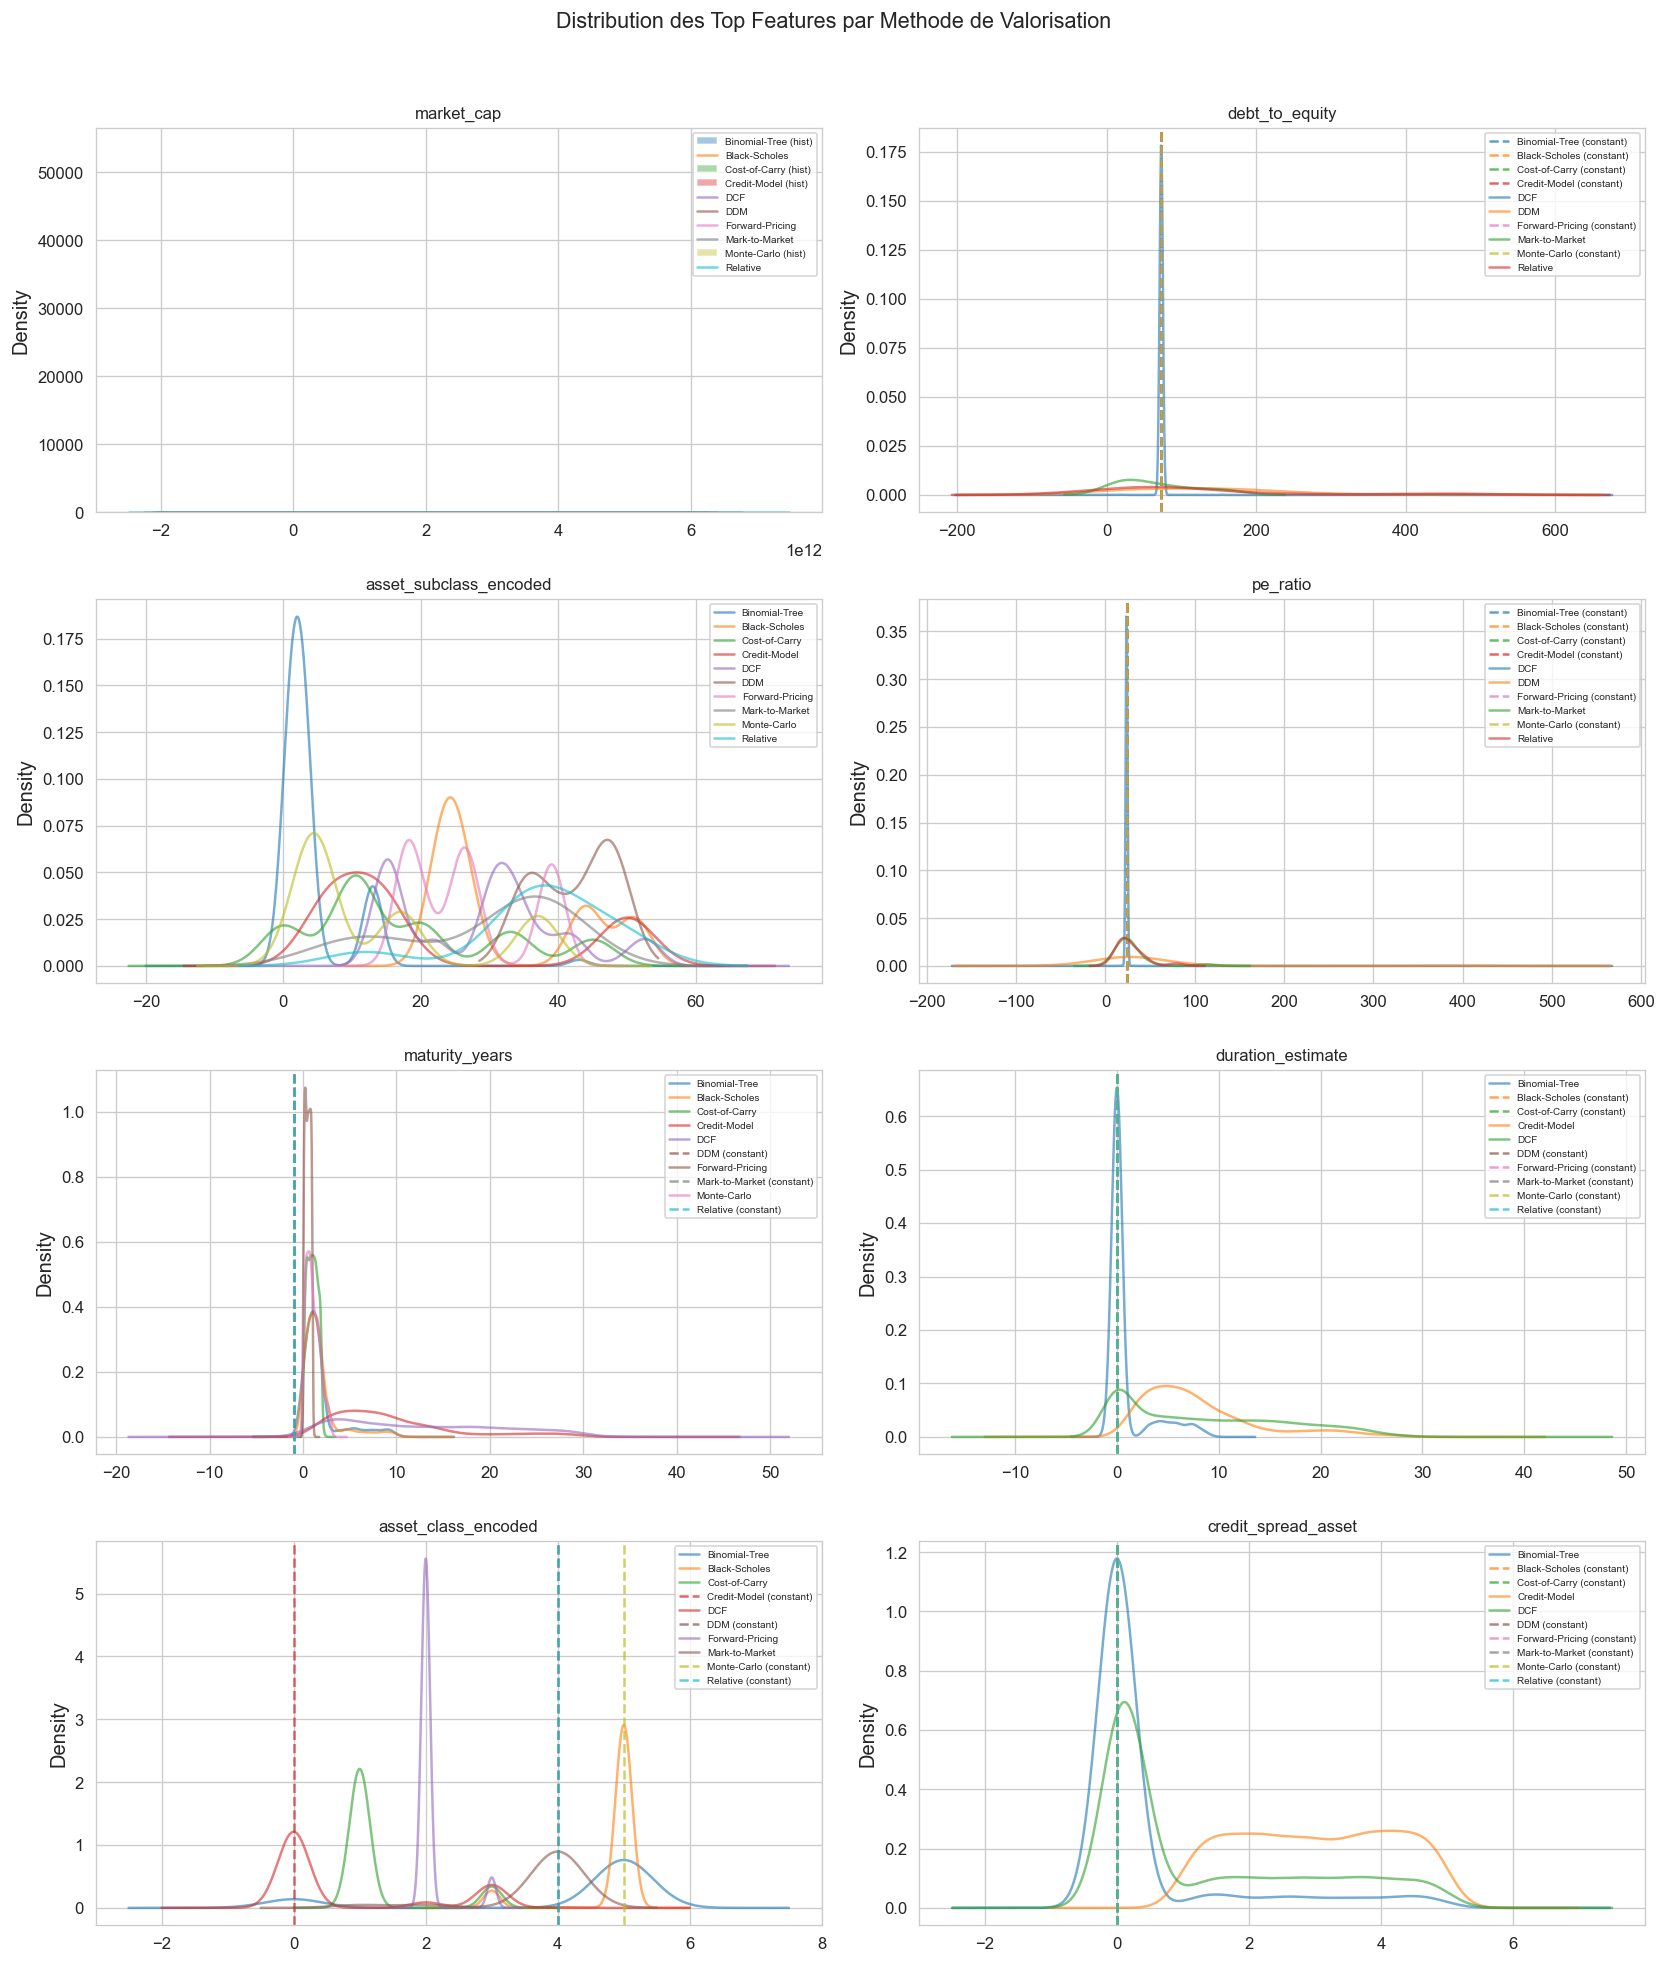

In [28]:
# Histogramme des top features discriminantes
top_feats = var_series.head(8).index.tolist()
n_plots = len(top_feats)
n_cols = 2
n_rows = (n_plots + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    for cls_idx, cls_name in enumerate(le_target.classes_):
        vals = X.loc[y == cls_idx, feat].dropna()
        if len(vals) > 10:
            # Check if values have sufficient variance for KDE
            if vals.std() > 1e-10:  # Avoid singular covariance matrix
                try:
                    vals.plot(kind="kde", ax=ax, label=cls_name, alpha=0.6)
                except (np.linalg.LinAlgError, ValueError) as e:
                    # Fallback: use histogram or just skip
                    print(f"  Warning: KDE failed for {feat} - {cls_name}: {str(e)[:50]}")
                    # Alternative: plot histogram instead
                    ax.hist(vals, bins=10, alpha=0.4, label=f"{cls_name} (hist)", density=True)
            else:
                # For constant values, plot a vertical line or histogram
                unique_vals = vals.unique()
                if len(unique_vals) == 1:
                    # Single constant value - plot vertical line
                    ax.axvline(unique_vals[0], color='C' + str(cls_idx), 
                               linestyle='--', alpha=0.7, label=f"{cls_name} (constant)")
                else:
                    # Very low variance but not constant - use histogram
                    ax.hist(vals, bins=10, alpha=0.4, label=f"{cls_name} (hist)", density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=6)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des Top Features par Methode de Valorisation", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "top_features_by_method.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Sauvegarde du Dataset Final


In [30]:
# ── Sauvegarder le dataset enrichi complet (avec colonnes texte) ──
output_full = PROCESSED / "features_final.parquet"
output_csv  = PROCESSED / "features_final.csv"

df_clean.to_parquet(output_full, index=False)
df_clean.to_csv(output_csv, index=False)
print(f"Dataset complet sauvegarde :")
print(f"  Parquet : {output_full}")
print(f"  CSV     : {output_csv}")

# ── Sauvegarder X et y separement (prets pour le ML) ─────────
import joblib

output_dir = Path("models")
output_dir.mkdir(exist_ok=True)

joblib.dump(X, output_dir / "X_features.pkl")
joblib.dump(y, output_dir / "y_target.pkl")
joblib.dump(le_target, output_dir / "label_encoder_target.pkl")
joblib.dump(label_encoders, output_dir / "feature_label_encoders.pkl")

print(f"\nMatrices ML sauvegardees :")
print(f"  X : {output_dir / 'X_features.pkl'}")
print(f"  y : {output_dir / 'y_target.pkl'}")
print(f"  Target encoder : {output_dir / 'label_encoder_target.pkl'}")
print(f"  Feature encoders : {output_dir / 'feature_label_encoders.pkl'}")

Dataset complet sauvegarde :
  Parquet : data_valuation_project\processed\features_final.parquet
  CSV     : data_valuation_project\processed\features_final.csv

Matrices ML sauvegardees :
  X : models\X_features.pkl
  y : models\y_target.pkl
  Target encoder : models\label_encoder_target.pkl
  Feature encoders : models\feature_label_encoders.pkl


---
## 7. Résumé Final


In [31]:
print("=" * 65)
print("  RESUME — PREPARATION DES DONNEES TERMINEE")
print("=" * 65)

print(f"""
  Source du dataset       : {source_name}
  Echantillons totaux     : {len(df_clean):,}
  Features structurelles  : 14
  Features d'enrichissement : {X.shape[1] - 14}
  Features totales (X)    : {X.shape[1]}
  Classes cibles          : {len(le_target.classes_)}
  Ratio d'imbalance       : {pd.Series(y).value_counts().max() / pd.Series(y).value_counts().min():.1f}:1
  NaN restants            : {X.isna().sum().sum()}
  
  Fichiers produits :
    - {PROCESSED / 'features_final.parquet'}
    - {PROCESSED / 'features_final.csv'}
    - models/X_features.pkl
    - models/y_target.pkl
    - models/label_encoder_target.pkl
    - models/feature_label_encoders.pkl
  
  Figures EDA : {FIG_DIR}/
    - target_distribution.png
    - asset_method_heatmap.png
    - feature_heatmap_bool.png
    - maturity_distribution.png
    - ifrs_level_methods.png
    - ordinal_distributions.png
    - subclass_method_heatmap.png
    - correlation_matrix.png
    - top_features_by_method.png
  
  Prochaine etape : Phase 3 — Model Development (04_model_training.ipynb)
""")

  RESUME — PREPARATION DES DONNEES TERMINEE

  Source du dataset       : Tier 3 (diversifie)
  Echantillons totaux     : 12,859
  Features structurelles  : 14
  Features d'enrichissement : 20
  Features totales (X)    : 34
  Classes cibles          : 10
  Ratio d'imbalance       : 246.7:1
  NaN restants            : 25718
  
  Fichiers produits :
    - data_valuation_project\processed\features_final.parquet
    - data_valuation_project\processed\features_final.csv
    - models/X_features.pkl
    - models/y_target.pkl
    - models/label_encoder_target.pkl
    - models/feature_label_encoders.pkl
  
  Figures EDA : reports\figures/
    - target_distribution.png
    - asset_method_heatmap.png
    - feature_heatmap_bool.png
    - maturity_distribution.png
    - ifrs_level_methods.png
    - ordinal_distributions.png
    - subclass_method_heatmap.png
    - correlation_matrix.png
    - top_features_by_method.png
  
  Prochaine etape : Phase 3 — Model Development (04_model_training.ipynb)



In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTENC # Ideal for datasets with mixed types (Categorical + Numerical)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [41]:
# -------------------------------------------------------------------------
# Step 1: Load your combined datasets
# -------------------------------------------------------------------------
# df = pd.read_csv('processed/labeled_valuation_dataset.csv') # Or your merged dataframe

print(f"Initial Shape: {df.shape}")
print(f"Initial Missing Values Count: {df.isna().sum().sum()}")

Initial Shape: (12859, 15)
Initial Missing Values Count: 0


In [42]:
# -------------------------------------------------------------------------
# Step 2: Robust Handling of Missing Values (NaNs)
# -------------------------------------------------------------------------
# Identify column types automatically
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Drop the target from feature processing if present
target_col = 'Valuation_Method' # Adjust this to your exact target column name
if target_col in cat_cols:
    cat_cols.remove(target_col)
elif target_col in num_cols:
    num_cols.remove(target_col)

# A. Categorical missing values: Fill with an explicit 'Missing/Not Applicable' category
for col in cat_cols:
    df[col] = df[col].astype(str).replace(['nan', 'None', 'NaN'], 'Missing')

# B. Numerical missing values: Fill with median or structural 0 depending on asset characteristics
# Here we use a safe median imputer to preserve distribution center without skewing outliers
num_imputer = SimpleImputer(strategy='median')
if num_cols:
    df[num_cols] = num_imputer.fit_transform(df[num_cols])

print(f"Missing Values after cleaning: {df.isna().sum().sum()}")

Missing Values after cleaning: 0


In [43]:
# -------------------------------------------------------------------------
# Step 3: Encoding Categorical Features for Resampling
# -------------------------------------------------------------------------
feature_encoders = {}
df_encoded = df.copy()

# Set the correct target column name as shown in your dataset
target_col = 'recommended_method'

# Define numeric and categorical feature columns (excluding the target)
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_encoded.select_dtypes(exclude=[np.number]).columns.tolist()

# Ensure target_col is completely separate from features list
if target_col in cat_cols: cat_cols.remove(target_col)
if target_col in num_cols: num_cols.remove(target_col)

# Encode Categorical features
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    feature_encoders[col] = le

# Encode the Target Class
target_encoder = LabelEncoder()
df_encoded[target_col] = target_encoder.fit_transform(df_encoded[target_col].astype(str))

print(f"✅ Target column '{target_col}' successfully found and encoded!")

✅ Target column 'recommended_method' successfully found and encoded!


In [44]:
# Step 4: Split First to Avoid Data Leakage
X = df_encoded[num_cols + cat_cols]
y = df_encoded[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set class distribution before balancing:\n{y_train.value_counts()}")


Training set class distribution before balancing:
recommended_method
4    3552
1    1440
2    1242
3    1236
6     946
8     929
0     890
5      19
7      18
9      15
Name: count, dtype: int64


In [45]:
# Step 5: Address Class Imbalance with class_weight="balanced"

# Instead of SMOTE-NC, we'll use class_weight parameter in the model
# This preserves the original training data without resampling

print(f"\nTraining set class distribution before balancing:\n{y_train.value_counts()}")

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))

print(f"\nClass weights to be applied:")
for cls, weight in class_weight_dict.items():
    print(f"  Class '{cls}': {weight:.4f}")

# When training your model, use class_weight='balanced'
# Example:
# model = RandomForestClassifier(class_weight='balanced', random_state=42)
# model.fit(X_train, y_train)

print(f"\nTraining set class distribution (unchanged):\n{y_train.value_counts()}")


Training set class distribution before balancing:
recommended_method
4    3552
1    1440
2    1242
3    1236
6     946
8     929
0     890
5      19
7      18
9      15
Name: count, dtype: int64

Class weights to be applied:
  Class '0': 1.1558
  Class '1': 0.7144
  Class '2': 0.8283
  Class '3': 0.8323
  Class '4': 0.2896
  Class '5': 54.1421
  Class '6': 1.0874
  Class '7': 57.1500
  Class '8': 1.1073
  Class '9': 68.5800

Training set class distribution (unchanged):
recommended_method
4    3552
1    1440
2    1242
3    1236
6     946
8     929
0     890
5      19
7      18
9      15
Name: count, dtype: int64


In [47]:
# Step 6: Save Cleaned & Balanced Outputs

# Export the structured, processed training artifacts for Phase 4 (Model Development)
import joblib
from pathlib import Path

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Save matrices
joblib.dump(X_train, models_dir / 'X_train_balanced.pkl')
joblib.dump(y_train, models_dir / 'y_train_balanced.pkl')
joblib.dump(X_val, models_dir / 'X_val.pkl')
joblib.dump(y_val, models_dir / 'y_val.pkl')

# Save Encoders to decode variables seamlessly during model evaluation
joblib.dump(target_encoder, models_dir / 'label_encoder_target.pkl')
joblib.dump(feature_encoders, models_dir / 'feature_label_encoders.pkl')

print("\nProcessing complete. Balanced training files saved to models/ directory.")


Processing complete. Balanced training files saved to models/ directory.


In [51]:
# Post-Processing Verification Check

print("="*50)
print("       VALUSENSE DATASET HEALTH CHECK REPORT       ")
print("="*50)

# 1. Verify Shapes
print(f"🔹 Training Features Shape   : {X_train.shape}")
print(f"🔹 Training Target Shape     : {y_train.shape}")
print(f"🔹 Validation Features Shape : {X_val.shape}")
print(f"🔹 Validation Target Shape   : {y_val.shape}\n")

# 2. Check for remaining Missing Values (Should be 0)
train_nans = pd.DataFrame(X_train, columns=X.columns).isna().sum().sum()
val_nans = X_val.isna().sum().sum()
print(f"🔹 Missing values (NaNs) in Train Set      : {train_nans}")
print(f"🔹 Missing values (NaNs) in Validation Set : {val_nans}")
if train_nans == 0 and val_nans == 0:
    print("   ✅ SUCCESS: All missing values have been successfully resolved!")
else:
    print("   ❌ WARNING: There are still missing values remaining.")

# 3. Check Target Balance (Should be equal across classes for Train)
print("\n🔹 Resampled Training Class Balance (y_train_resampled):")
# Mapping back to original labels using your target encoder for clear readability
original_train_labels = target_encoder.inverse_transform(y_train)
print(pd.Series(original_train_labels).value_counts())

print("\n🔹 Original Validation Class Balance (y_val) [Stratified]:")
original_val_labels = target_encoder.inverse_transform(y_val)
print(pd.Series(original_val_labels).value_counts())

print("="*50)

       VALUSENSE DATASET HEALTH CHECK REPORT       
🔹 Training Features Shape   : (10287, 14)
🔹 Training Target Shape     : (10287,)
🔹 Validation Features Shape : (2572, 14)
🔹 Validation Target Shape   : (2572,)

🔹 Missing values (NaNs) in Train Set      : 0
🔹 Missing values (NaNs) in Validation Set : 0
   ✅ SUCCESS: All missing values have been successfully resolved!

🔹 Resampled Training Class Balance (y_train_resampled):
DCF                3552
Black-Scholes      1440
Cost-of-Carry      1242
Credit-Model       1236
Forward-Pricing     946
Monte-Carlo         929
Binomial-Tree       890
DDM                  19
Mark-to-Market       18
Relative             15
Name: count, dtype: int64

🔹 Original Validation Class Balance (y_val) [Stratified]:
DCF                888
Black-Scholes      360
Cost-of-Carry      311
Credit-Model       309
Forward-Pricing    237
Monte-Carlo        232
Binomial-Tree      223
DDM                  5
Mark-to-Market       4
Relative             3
Name: count, dtyp